<a href="https://colab.research.google.com/github/tustus1022-ui/esaa/blob/main/ESAA_YB_WEEK9_transcription2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

캐글 필사 (https://www.kaggle.com/code/ash316/eda-to-prediction-dietanic)

# **EDA To Prediction(DieTanic)**
Part1: Exploratory Data Analysis(EDA):
1) Analysis of the features.

2)Finding any relations or trends considering multiple features.

Part2: Feature Engineering and Data Cleaning:
1) Adding any few features.

2) Removing redundant features.

3) Converting features into suitable form for modeling.

Part3: Predictive Modeling
1) Running Basic Algorithms.

2) Cross Validation.

3) Ensembling.

4) Important Features Extraction.

## Part1: Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
data=pd.read_csv('titanic_train.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 전체 null 값 확인
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


=> Age, Cabin, Embarked에 null values가 존재함.

## How many Survived?

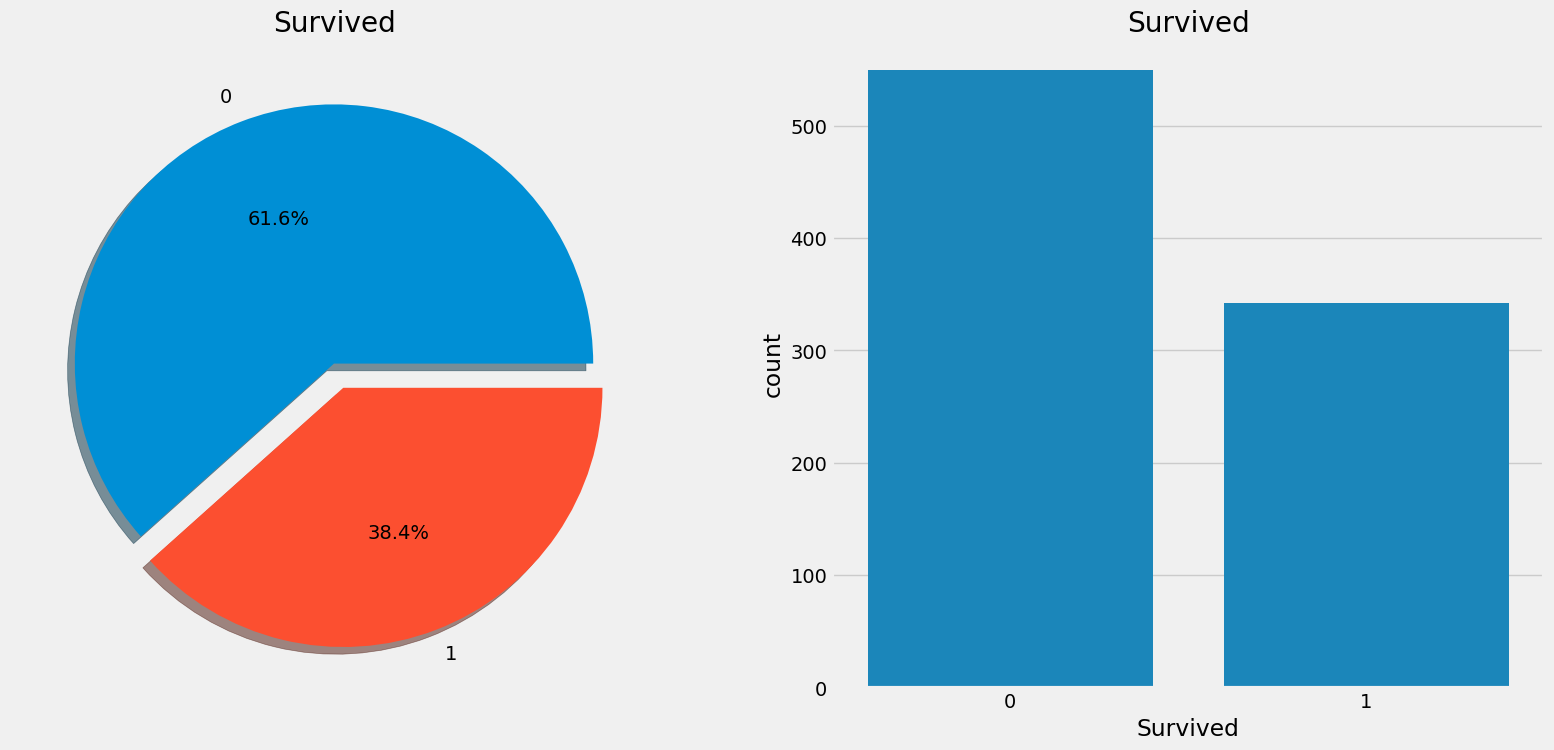

In [6]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Survived')
ax[0].set_ylabel('')
sns.countplot(x='Survived',data=data,ax=ax[1])
ax[1].set_title('Survived')
plt.show()

38.4%만이 사고에서 살아남았다. 데이터에서 더 나은 인사이트를 얻고 어떤 카테고리의 승객이 살아남았는지, 누가 살아남지 못했는지 더 자세히 알아봐야 한다.

## Types Of Features

Categorical Features:

A categorical variable is one that has two or more categories and each value in that feature can be categorised by them.For example, gender is a categorical variable having two categories (male and female). Now we cannot sort or give any ordering to such variables. They are also known as **Nominal Variables.**

**Categorical Features in the dataset: Sex,Embarked.**

Ordinal Features:

An ordinal variable is similar to categorical values, but the difference between them is that we can have relative ordering or sorting between the values. For eg: If we have a feature like **Height** with values **Tall, Medium, Short**, then Height is a ordinal variable. Here we can have a relative sort in the variable.

**Ordinal Features in the dataset: PClass**

Continous Feature:
A feature is said to be continous if it can take values between any two points or between the minimum or maximum values in the features column.

**Continous Features in the dataset: Age**

## Analysing The Features

### Sex -> Categorical Feature

In [7]:
data.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

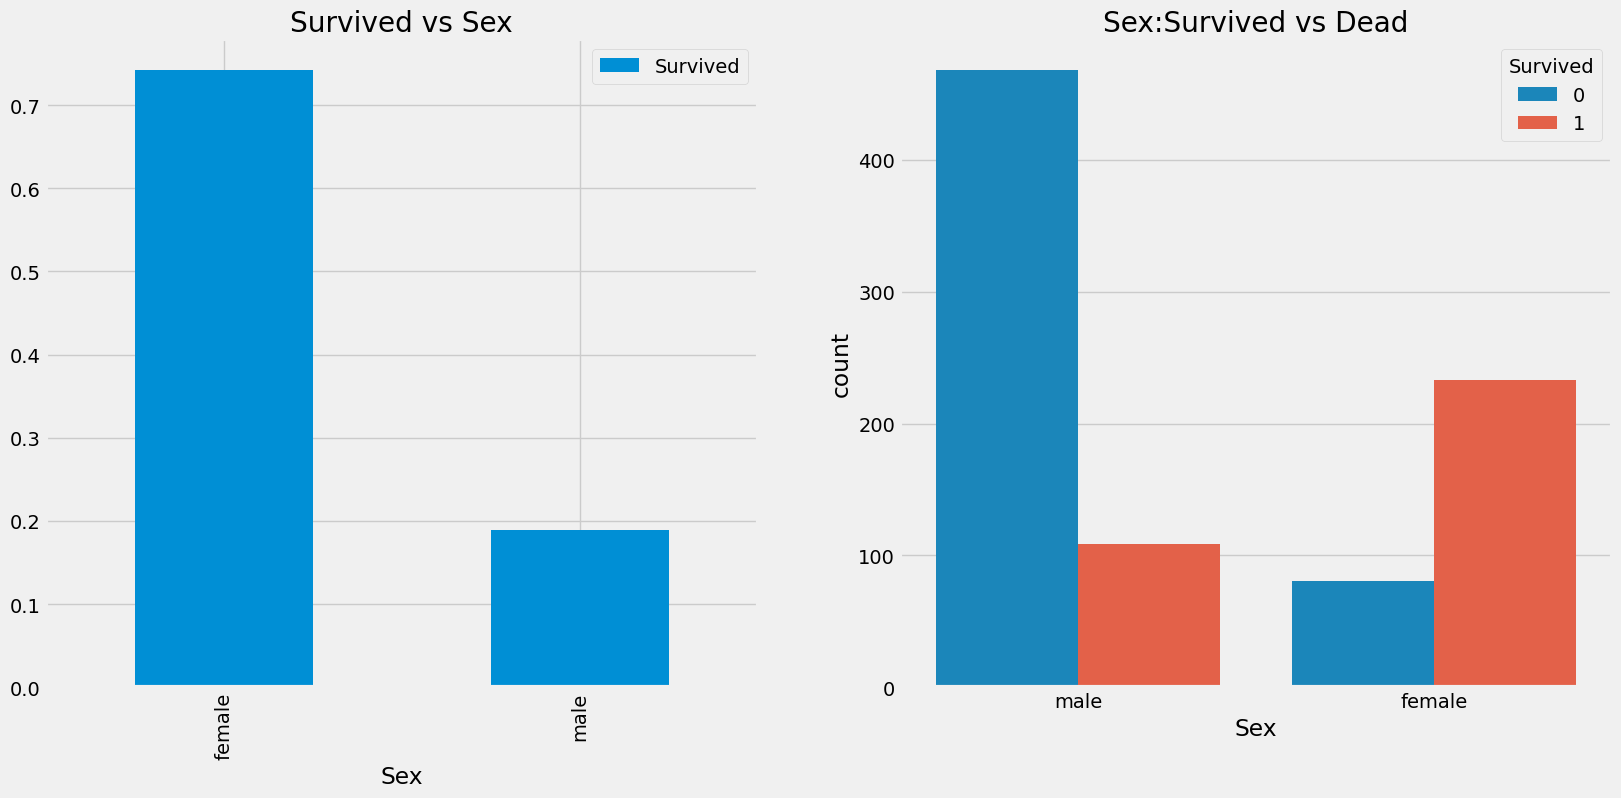

In [8]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot(x='Sex',hue='Survived',data=data,ax=ax[1])
ax[1].set_title('Sex:Survived vs Dead')
plt.show()

배에 타고 있는 남성의 수는 여성의 수보다 훨씬 많다. 그럼에도 불구하고 여성의 수는 남성의 수보다 거의 두 배나 많다. 배에 타고 있는 여성의 생존율은 약 75%인 반면, 남성의 생존율은 약 18~19%이다.

### Pclass -> Ordinal Feature

In [9]:
pd.crosstab(data.Pclass,data.Survived,margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


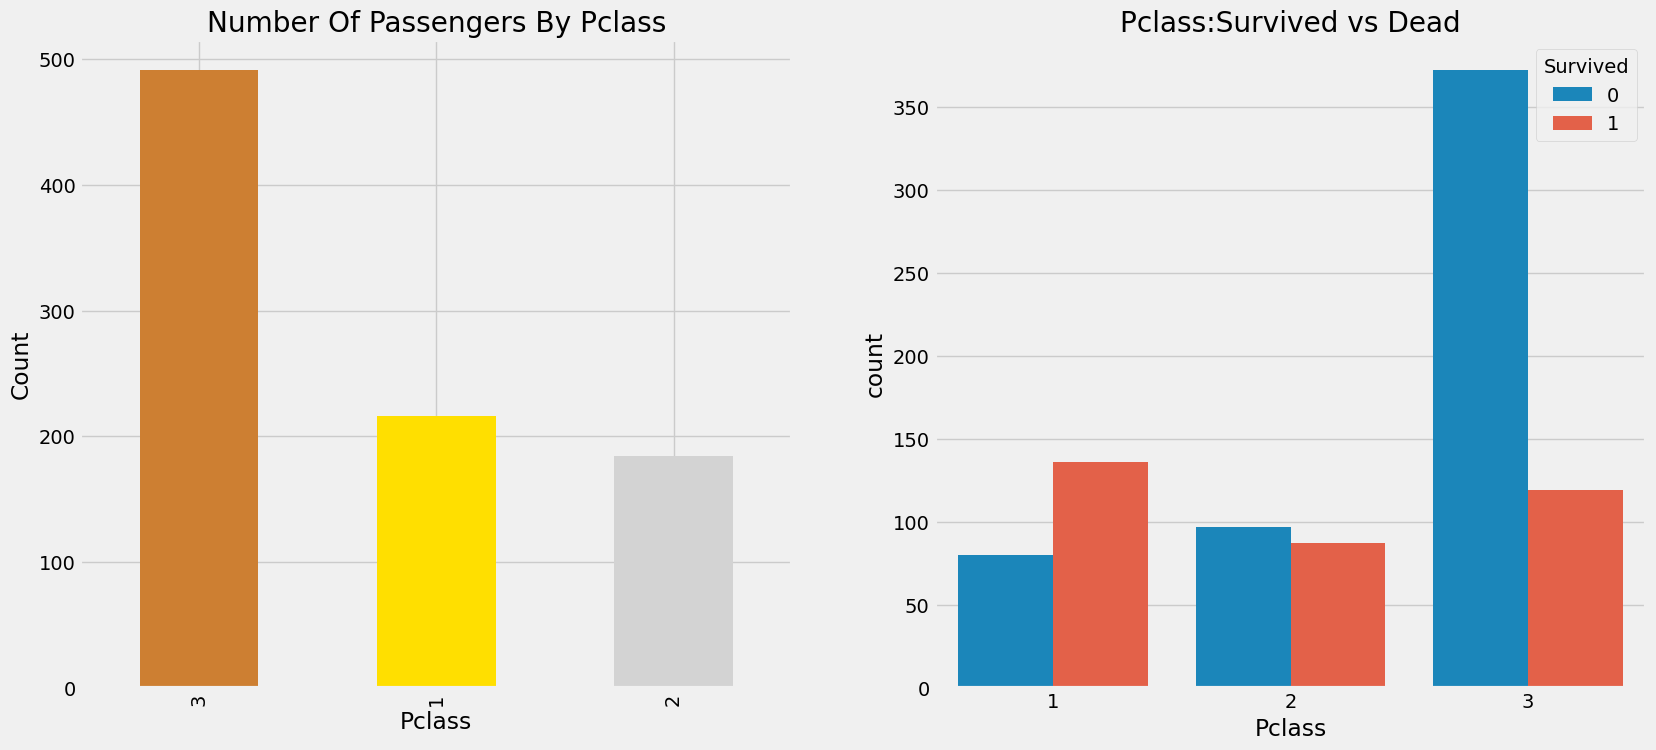

In [10]:
f,ax=plt.subplots(1,2,figsize=(18,8))
data['Pclass'].value_counts().plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'],ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('Count')
sns.countplot(x='Pclass',hue='Survived',data=data,ax=ax[1])
ax[1].set_title('Pclass:Survived vs Dead')
plt.show()

P클래스 1의 승객들은 구조 과정에서 매우 높은 우선순위를 부여받았음을 분명히 알 수 있다. P클래스 3의 승객 수는 훨씬 많았지만, 여전히 생존율은 약 25%로 매우 낮다.

P클래스 1의 생존율은 약 63%이고 P클래스 2의 생존율은 약 48%이다. 따라서 돈과 지위가 중요하다는 것을 알 수 있다.

### Sex 와 Pclass를 활용해 생존율 확인

In [11]:
pd.crosstab([data.Sex,data.Survived],data.Pclass,margins=True).style.background_gradient(cmap='summer_r')

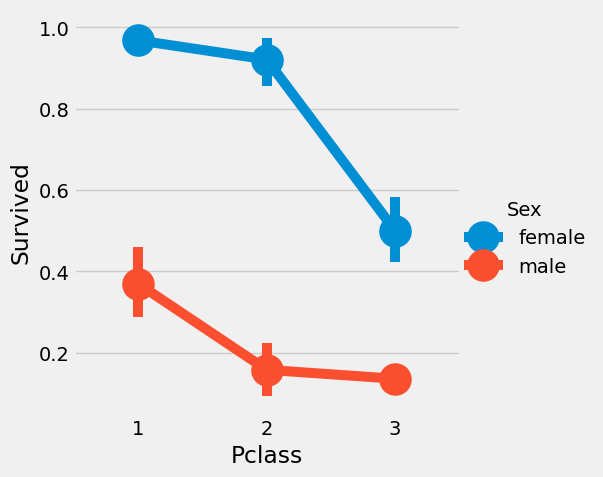

In [14]:
sns.catplot(x='Pclass',y='Survived',hue='Sex',data=data, kind='point')
plt.show()

CrossTab과 FactorPlot을 살펴보면, Pclass1 여성의 생존율이 약 95-96%임을 쉽게 추론할 수 있다. 이는 Pclass1 여성 94명 중 3명만이 사망했기 때문이다.

P급에 관계없이 구조할 때 여성이 최우선 순위를 차지한 것은 분명하다. P급 남성도 생존율이 매우 낮다.


### Age -> Continous Feature

In [15]:
print('Oldest Passenger was of:',data['Age'].max(),'Years')
print('Youngest Passenger was of:',data['Age'].min(),'Years')
print('Average Age on the ship:',data['Age'].mean(),'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.69911764705882 Years


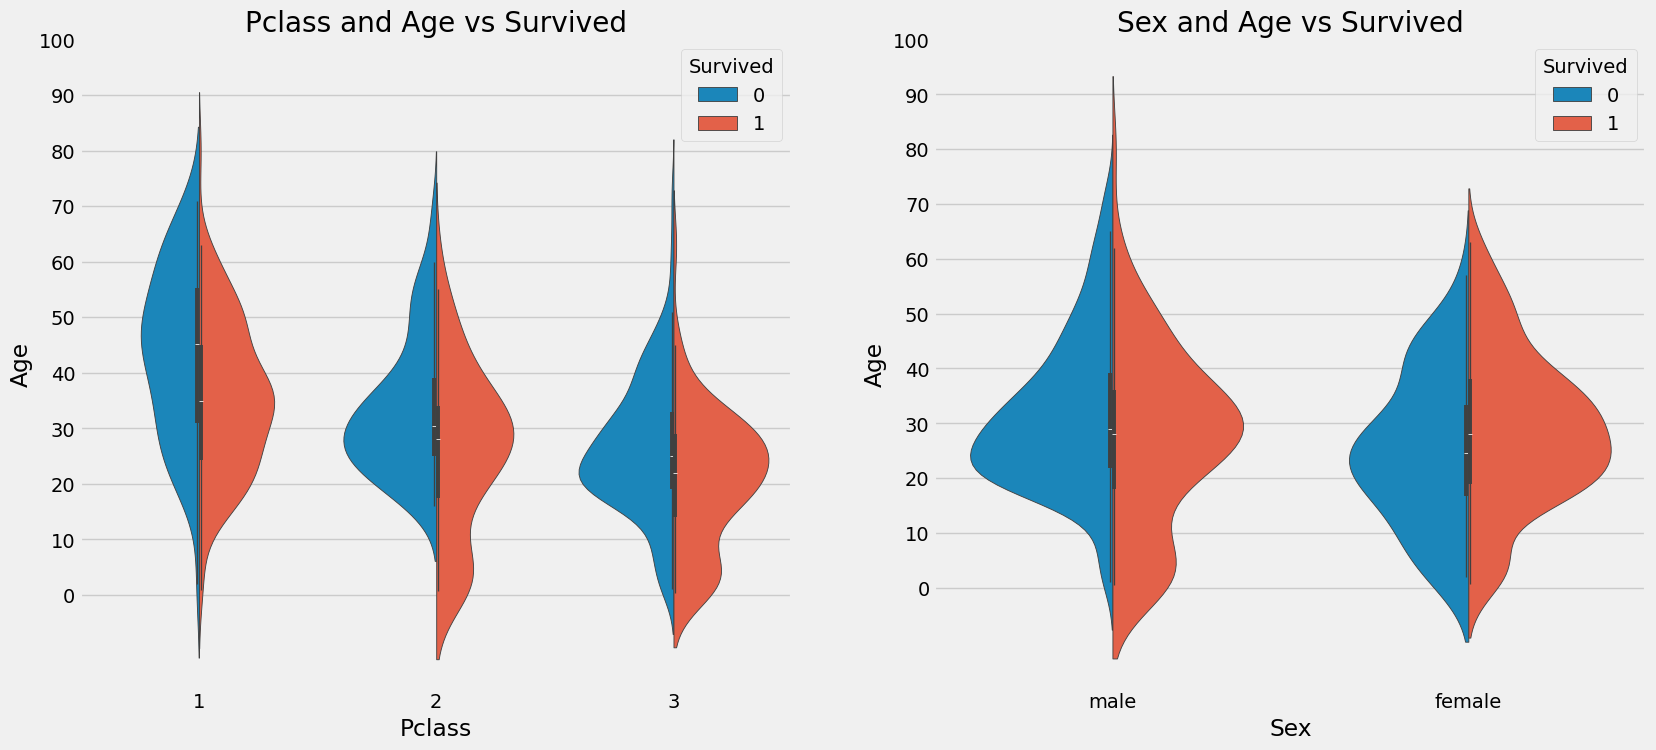

In [17]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot(x="Pclass",y="Age", hue="Survived", data=data,split=True,ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))
sns.violinplot(x="Sex",y="Age", hue="Survived", data=data,split=True,ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()

1. P클래스에 따라 어린이의 수가 증가하며, 10세 미만의 승객(즉, 어린이)의 생존율은 P클래스에 관계없이 양호한 것으로 보인다.
2. Pclass1에서 20-50세 사이의 승객의 생존 확률은 높으며, 여성에게는 더욱 높게 나타난다.
3. 남성의 경우 나이가 많을수록 생존 확률이 감소한다.

앞서 보았듯이 연령 함수에는 177개의 널 값이 있다. 이러한 NaN 값을 대체하기 위해 데이터셋의 평균 연령을 할당할 수 있다.

하지만 문제는 다양한 연령대를 가진 사람들이 많다는 것이다. 평균 연령이 29세인 4세 아이를 배정할 수는 없다.

Name 피처를 살펴보면 이름에 Mr. 또는 Mr.s.와 같은 경례가 있는 것을 볼 수 있으므로 각 그룹에 Mr.와 Mrs.의 평균값을 할당할 수 있다.

In [18]:
data['Initial']=0
for i in data:
    data['Initial']=data.Name.str.extract('([A-Za-z]+)\.') # lets extract the Salutations

Name에서 이니셜을 성공적으로 추출했다.

In [19]:
# Checking the Initials with the Sex
pd.crosstab(data.Initial,data.Sex).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


Mlle 또는 Mme 와 같이 오타가 존재하므로 다른 값으로 바꿀 것이다.

In [20]:
data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)

In [21]:
# lets check the average age by Initials
data.groupby('Initial')['Age'].mean()

,Age
Initial,
Master,4.574167
Miss,21.860000
Mr,32.739609
Mrs,35.981818
Other,45.888889


### Filling NaN Ages

In [23]:
# Assigning the NaN Values with the Ceil values of the mean ages
data.loc[(data.Age.isnull())&(data.Initial=='Mr'),'Age']=33
data.loc[(data.Age.isnull())&(data.Initial=='Mrs'),'Age']=36
data.loc[(data.Age.isnull())&(data.Initial=='Master'),'Age']=5
data.loc[(data.Age.isnull())&(data.Initial=='Miss'),'Age']=22
data.loc[(data.Age.isnull())&(data.Initial=='Other'),'Age']=46

In [24]:
# So no null values left finally
data.Age.isnull().any()

np.False_

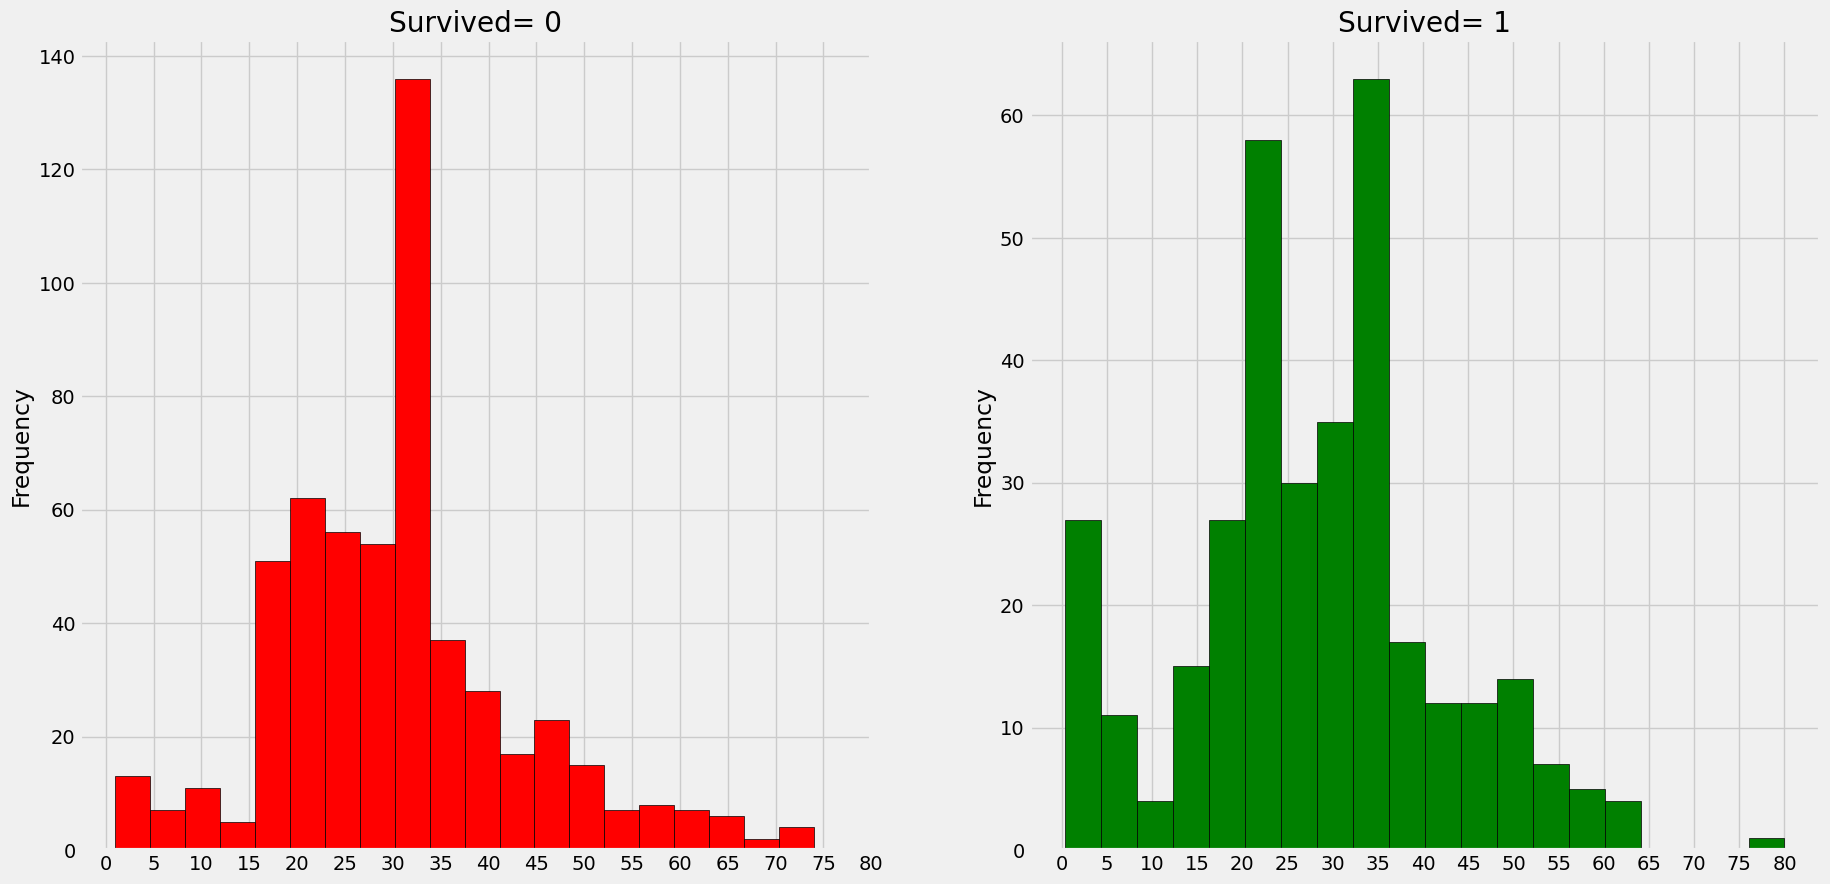

In [25]:
f,ax=plt.subplots(1,2,figsize=(20,10))
data[data['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
data[data['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

1. 유아(5세 미만)는 매우 많이 구조되었다. (여성 및 아동 우선 정책)
2. 가장 나이가 많은 승객이 구조되었다. (80세)
3. 최대 사망자 수는 30~40세 연령대였다.

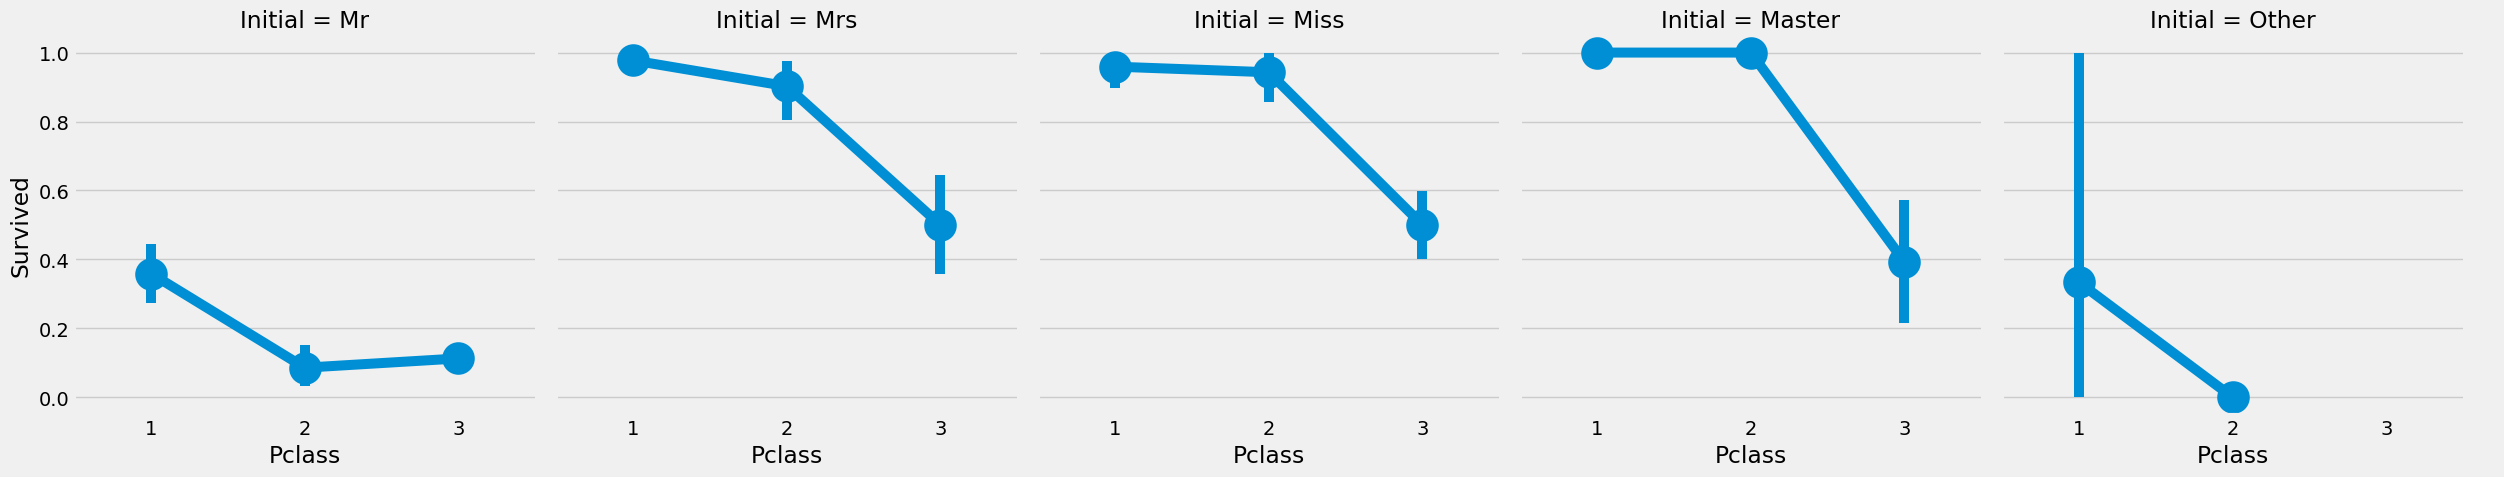

In [26]:
sns.catplot(x='Pclass',y='Survived',col='Initial',data=data, kind='point')
plt.show()

여성 및 아동 우선 정책은 class에 관계없이 적용됩니다.

### Embarked -> Categorical Value

In [27]:
pd.crosstab([data.Embarked,data.Pclass],[data.Sex,data.Survived],margins=True).style.background_gradient(cmap='summer_r')

### Chances for Survival by Port Of Embarkation

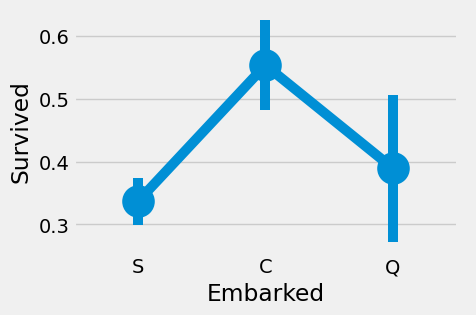

In [28]:
sns.catplot(x='Embarked',y='Survived',data=data, kind='point')
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

Port C의 생존 확률은 0.55로 가장 높고, Port S는 가장 낮다.

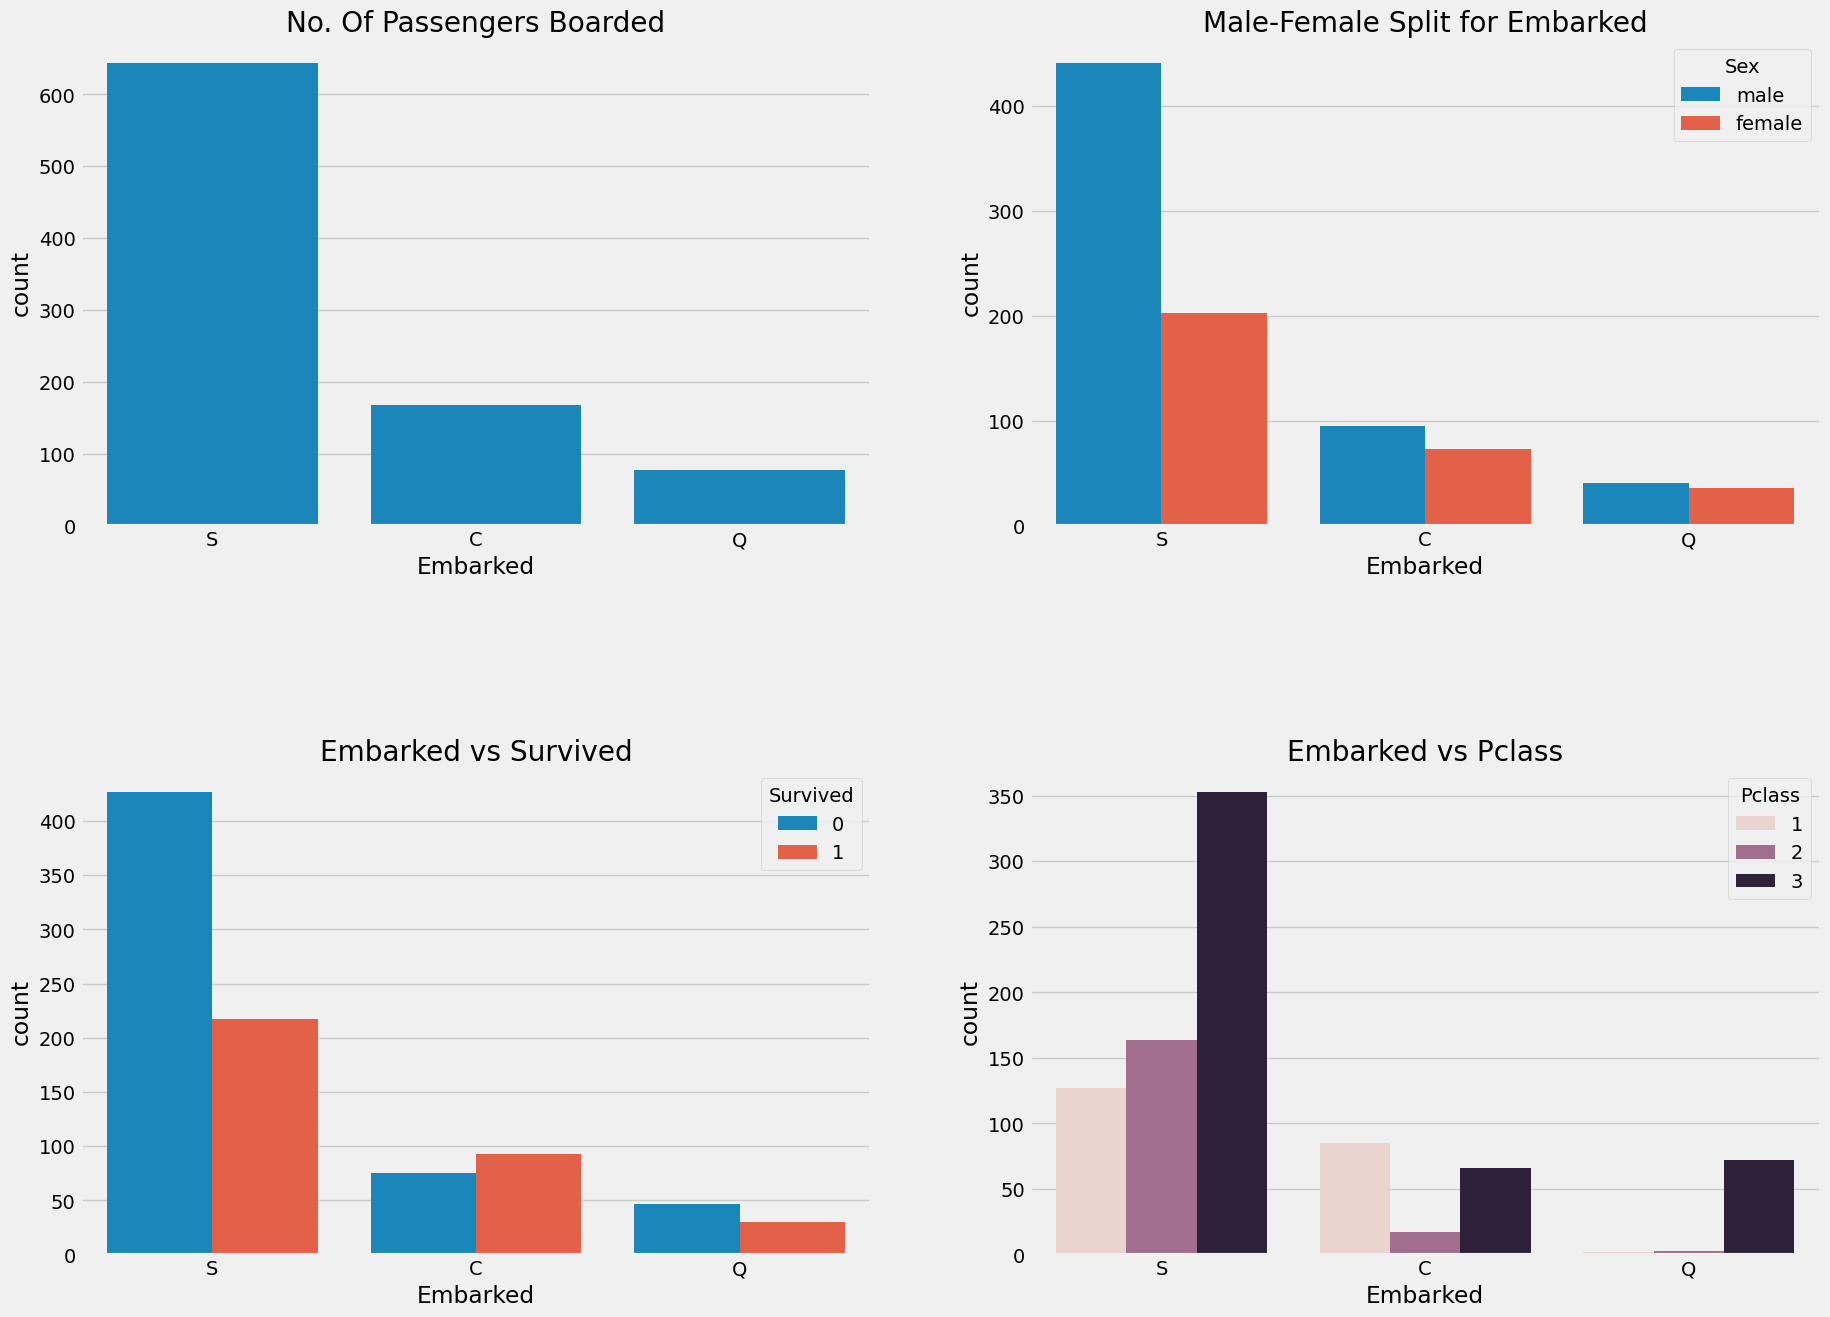

In [29]:
f,ax=plt.subplots(2,2,figsize=(20,15))
sns.countplot(x='Embarked',data=data,ax=ax[0,0])
ax[0,0].set_title('No. Of Passengers Boarded')
sns.countplot(x='Embarked',hue='Sex',data=data,ax=ax[0,1])
ax[0,1].set_title('Male-Female Split for Embarked')
sns.countplot(x='Embarked',hue='Survived',data=data,ax=ax[1,0])
ax[1,0].set_title('Embarked vs Survived')
sns.countplot(x='Embarked',hue='Pclass',data=data,ax=ax[1,1])
ax[1,1].set_title('Embarked vs Pclass')
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

1. S.Matority에서 탑승한 최대 승객은 대부분 Pclass 3에서 탑승했다.
2. C에서 온 승객들은 많은 비율이 살아남았기에 운이 좋은 것 같다. 그 이유는 아마 Pclass 1과 Pclass 2의 승객들을 구조했기 때문이다.
3. Embark S는 대부분의 부유한 사람들이 탑승한 항구로 보인다. 하지만 이곳은 약 81%의 Pclass 3의 승객들이 생존하지 못했기에 생존 확률이 매우 낮다.
4. Port Q는 승객의 거의 95%가 Pclass 3 출신이었다.

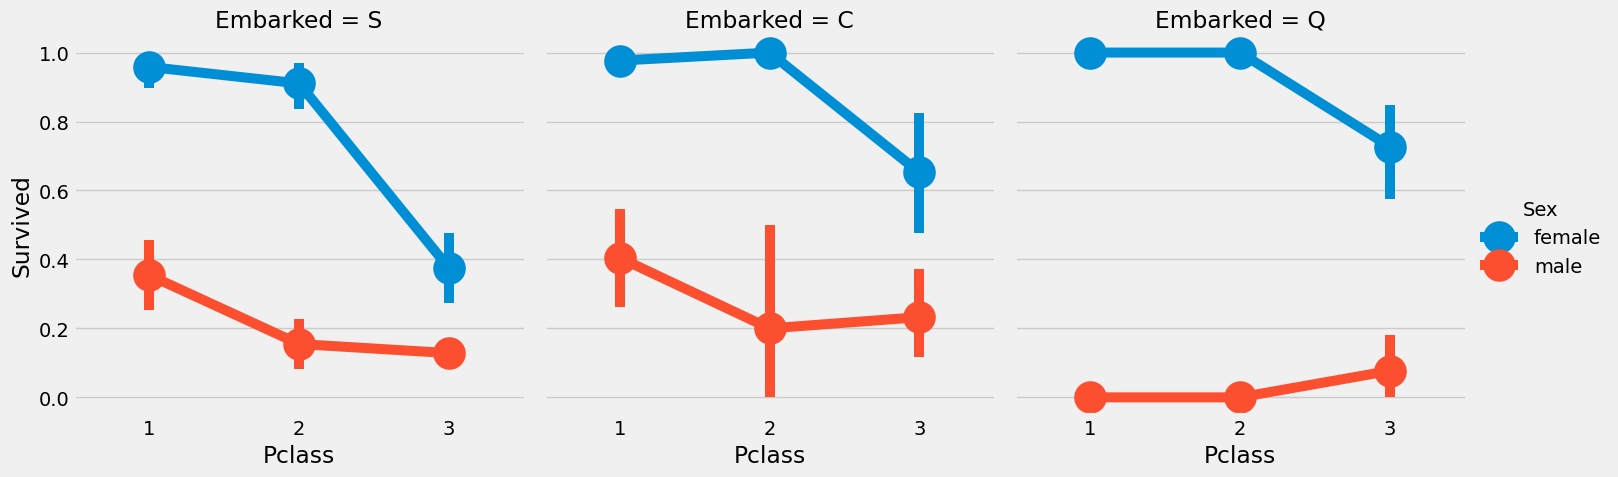

In [30]:
sns.catplot(x='Pclass',y='Survived',hue='Sex',col='Embarked',data=data, kind='point')
plt.show()

1. 여성의 생존 확률은 Pclass 1과 Pclass 2에 상관없이 거의 1이다.
2. Port S는 남성과 여성 모두의 생존율이 매우 낮기 때문에 Pclass 3 승객들에게 매우 불운하게 보인다. (돈 문제)
3. Port Q는 거의 모두 Pclass 3 출신이었기에 남성들에게 가장 운이 좋지 않아보인다.

### Filling Embarked NaN

Port S에서 최대 승객이 탑승한 것을 확인했으므로 NaN을 S로 대체한다.

In [31]:
data['Embarked'].fillna('S',inplace=True)

In [32]:
# Finally No NaN values
data.Embarked.isnull().any()

np.False_

### SibSip -> Discrete Feature

이 피처는 혼자이든 가족과 함께이든 상관없이 대표할 수 있다.

Sibling = brother, sister,stepbrother, stepsister

Spouse = husband, wife

In [33]:
pd.crosstab([data.SibSp],data.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


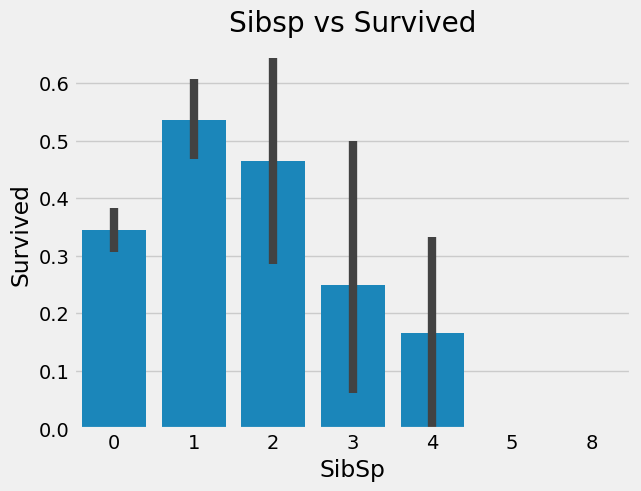

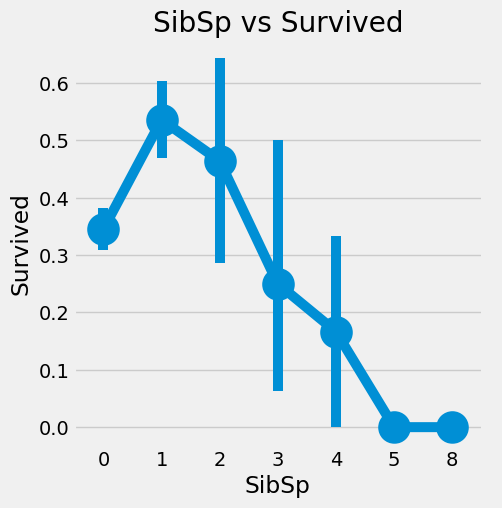

In [34]:
# catplot은 subplot이 Axes 위에 직접 그릴 수 없으므로 subplot 안에 직접 넣을 수 없음
sns.barplot(x='SibSp',y='Survived',data=data)
plt.title('Sibsp vs Survived')
sns.catplot(x='SibSp',y='Survived',data=data, kind='point')
plt.title('SibSp vs Survived')
plt.show()

In [35]:
pd.crosstab(data.SibSp,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


혼자 탑승한 경우 생존율은 34.5%이다. 형제자매의 수가 증가하면 그래프는 감소한다. 이는 가족이 탑승한 경우 자신보다는 가족을 구하려고 노력할 것이기 때문이다.

놀랍게도 5~8명의 가족의 생존율은 0%인데 그 이유는 Pclass에 있다. crosstab에 따르면 SibSp>3인 사람은 모두 Pclass 3에 속한다. Pclass 3(>3)의 모든 대가족이 사망한 것을 의미한다.

### Parch

In [36]:
pd.crosstab(data.Parch,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


crosstab은 다시 Pclass 3에 대가족들이 있다는 것을 보여준다.

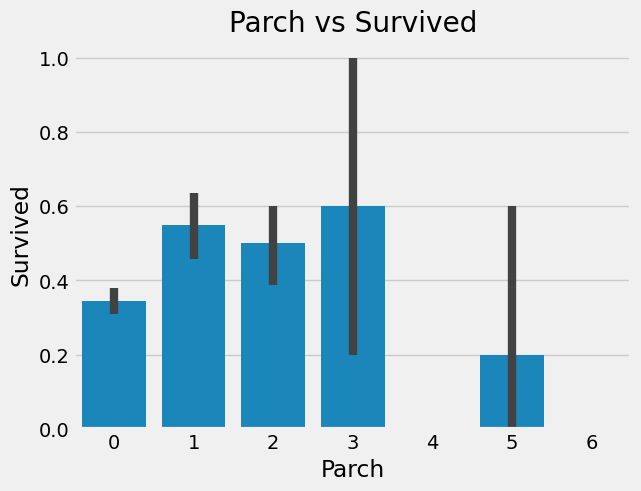

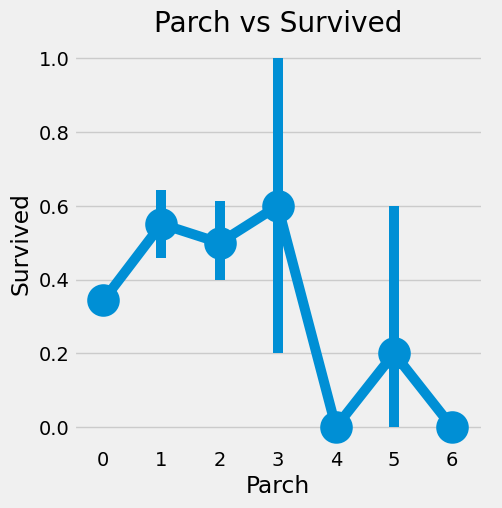

In [37]:
sns.barplot(x='Parch',y='Survived',data=data)
plt.title('Parch vs Survived')
sns.catplot(x='Parch',y='Survived',data=data, kind='point')
plt.title('Parch vs Survived')
plt.show()

여기에서도 결과는 꽤 비슷하다. 부모님이 탑승한 승객은 생존 확률이 더 높지만 숫자가 증가할수록 감소한다.

부모가 1~3명인 사람에게는 생존 확률이 높고, 부모가 4명 이상인 사람은 혼자 있는 것도 치명적이며 생존 확률이 낮아진다.

### Fare -> Continous Feature

In [38]:
print('Highest Fare was:',data['Fare'].max())
print('Lowest Fare was:',data['Fare'].min())
print('Average Fare was:',data['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.204207968574636


The lowest fare is 0.0. Wow!! a free luxorious ride.

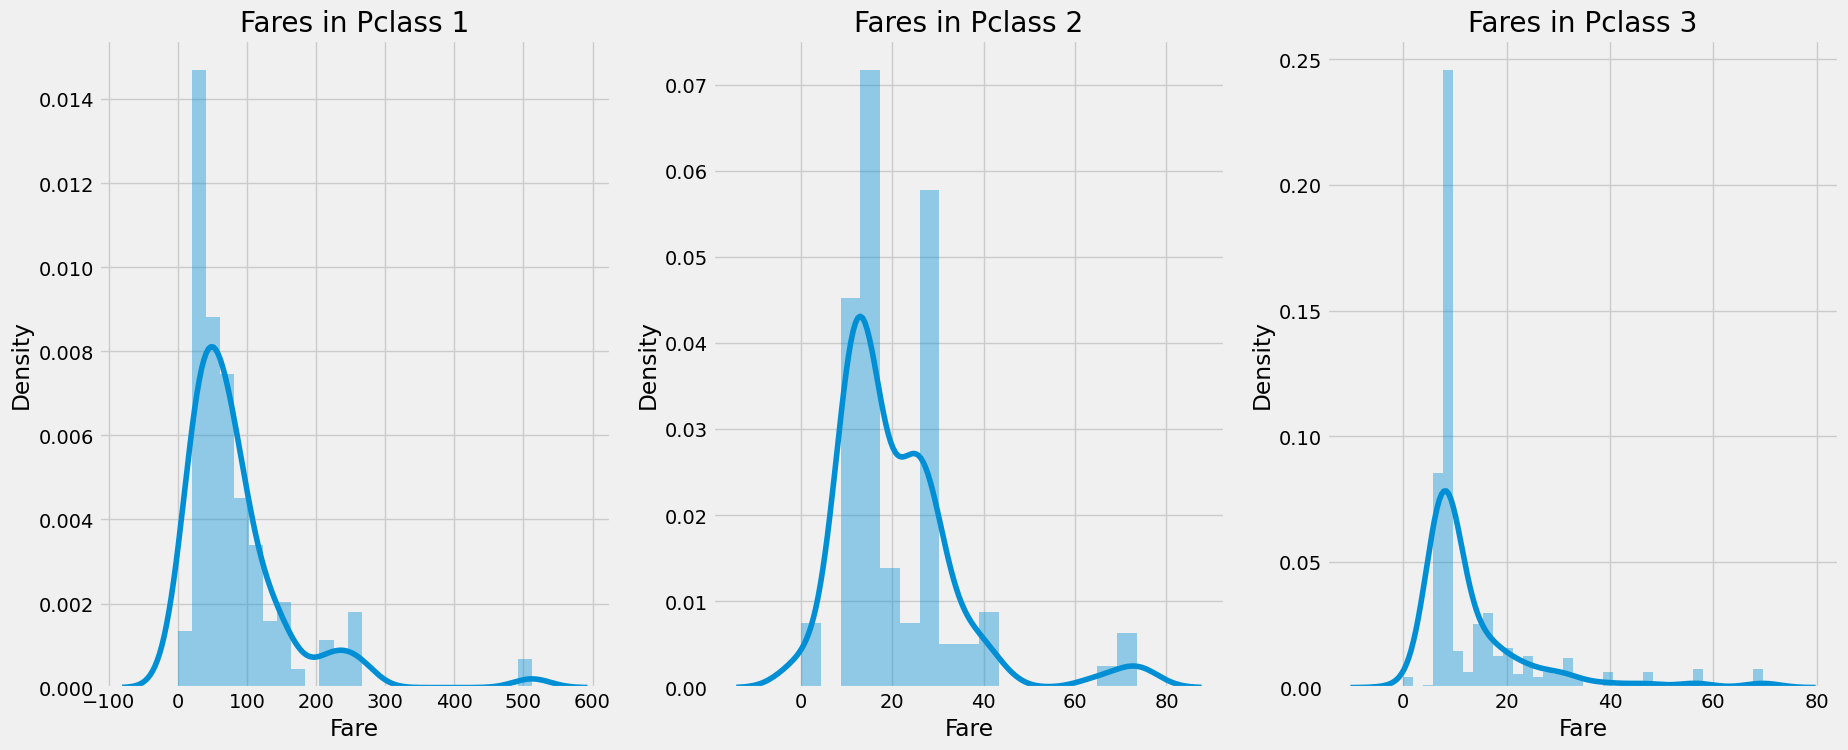

In [39]:
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.distplot(data[data['Pclass']==1].Fare,ax=ax[0])
ax[0].set_title('Fares in Pclass 1')
sns.distplot(data[data['Pclass']==2].Fare,ax=ax[1])
ax[1].set_title('Fares in Pclass 2')
sns.distplot(data[data['Pclass']==3].Fare,ax=ax[2])
ax[2].set_title('Fares in Pclass 3')
plt.show()

Pclass 1의 승객 요금에는 큰 분포가 있는 것으로 보이며 기준이 줄어들수록 이 분포는 계속 감소한다. 이것 또한 연속적이므로 binning을 활용해서 이산값으로 변환할 수 있다.

## Observations in a Nutshell for all features:
**Sex**: The chance of survival for women is high as compared to men.

**Pclass**:There is a visible trend that being a **1st class passenger** gives you better chances of survival. The survival rate for **Pclass3 is very low.** For **women**, the chance of survival from **Pclass1** is almost 1 and is high too for those from **Pclass2. Money Wins**!!!.

**Age**: Children less than 5-10 years do have a high chance of survival. Passengers between age group 15 to 35 died a lot.

**Embarked**: This is a very interesting feature. **The chances of survival at C looks to be better than even though the majority of Pclass1 passengers got up at S.** Passengers at Q were all from **Pclass3**.

**Parch+SibSp**: Having 1-2 siblings,spouse on board or 1-3 Parents shows a greater chance of probablity rather than being alone or having a large family travelling with you.

### Correlation Between The Features

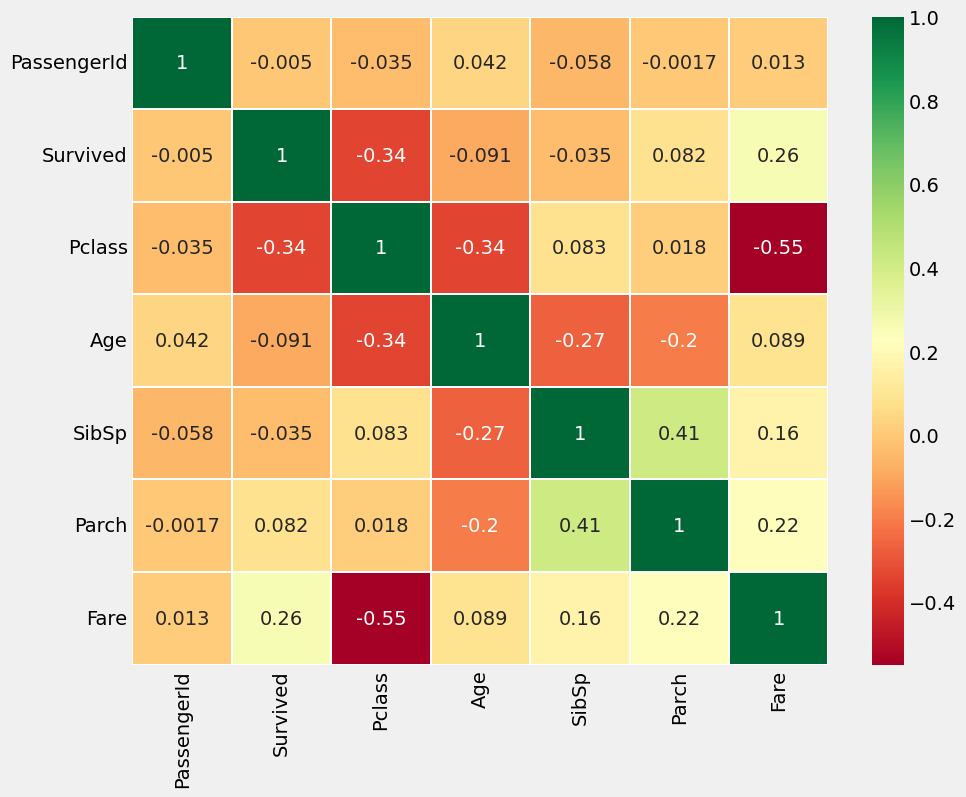

In [41]:
# data.corr() -> correlation matrix
cols = ['PassengerId','Survived','Pclass','Age','SibSp','Parch','Fare']
sns.heatmap(data[cols].corr(),annot=True,cmap='RdYlGn',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(10,8)
plt.show()

#### Interpreting The Heatmap
The first thing to note is that only the numeric features are compared as it is obvious that we cannot correlate between alphabets or strings. Before understanding the plot, let us see what exactly correlation is.

**POSITIVE CORRELATION**: If an **increase in feature A leads to increase in feature B, then they are positively correlated.** A value **1 means perfect positive correlation.**

**NEGATIVE CORRELATION**: If an** increase in feature A leads to decrease in feature B, then they are negatively correlated.** A value **-1 means perfect negative correlation.**

Now lets say that two features are highly or perfectly correlated, so the increase in one leads to increase in the other. This means that both the features are containing highly similar information and there is very little or no variance in information. This is known as **MultiColinearity **as both of them contains almost the same information.

So do you think we should use both of them as **one of them is redundant. **While making or training models, we should try to eliminate redundant features as it reduces training time and many such advantages.

Now from the above heatmap,we can see that the features are not much correlated. The highest correlation is between **SibSp and Parch i.e 0.41.** So we can carry on with all features.

## Part2: Feature Engineering and Data Cleaning

Now what is Feature Engineering?

특징이 포함된 데이터셋이 주어질 때마다 모든 특징이 중요할 필요는 없다. 제거해야 할 중복되는 특징이 많을 수 있다. 또한 다른 특징을 관찰하거나 추출하여 새로운 특징을 얻거나 추가할 수도 있다.

예를 들어 Name 피처를 사용하여 이니셜 피처를 얻는 것이 있다. 새로운 피처를 얻고 몇 가지 피처를 제거할 수 있는지 살펴보자. 또한 기존의 관련 피처를 예측 모델링에 적합한 형태로 변환할 것이다.

### Age_band
Problem With Age Feature:

As I have mentioned earlier that** Age is a continous feature**, there is a problem with Continous Variables in Machine Learning Models.

**Eg**:If I say to group or arrange Sports Person by **Sex**, We can easily segregate them by Male and Female.

Now if I say to group them by their **Age**, then how would you do it? If there are 30 Persons, there may be 30 age values. Now this is problematic.

We need to convert these **continous values into categorical values** by either Binning or Normalisation. I will be using binning i.e group a range of ages into a single bin or assign them a single value.

Okay so the maximum age of a passenger was 80. So lets divide the range from 0-80 into 5 bins. So 80/5=16. So bins of size 16.

In [42]:
data['Age_band']=0
data.loc[data['Age']<=16,'Age_band']=0
data.loc[(data['Age']>16)&(data['Age']<=32),'Age_band']=1
data.loc[(data['Age']>32)&(data['Age']<=48),'Age_band']=2
data.loc[(data['Age']>48)&(data['Age']<=64),'Age_band']=3
data.loc[data['Age']>64,'Age_band']=4
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_band
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2


In [43]:
# checking the number of passenegers in each band
data['Age_band'].value_counts().to_frame().style.background_gradient(cmap='summer')

,count
Age_band,
1,382
2,325
0,104
3,69
4,11


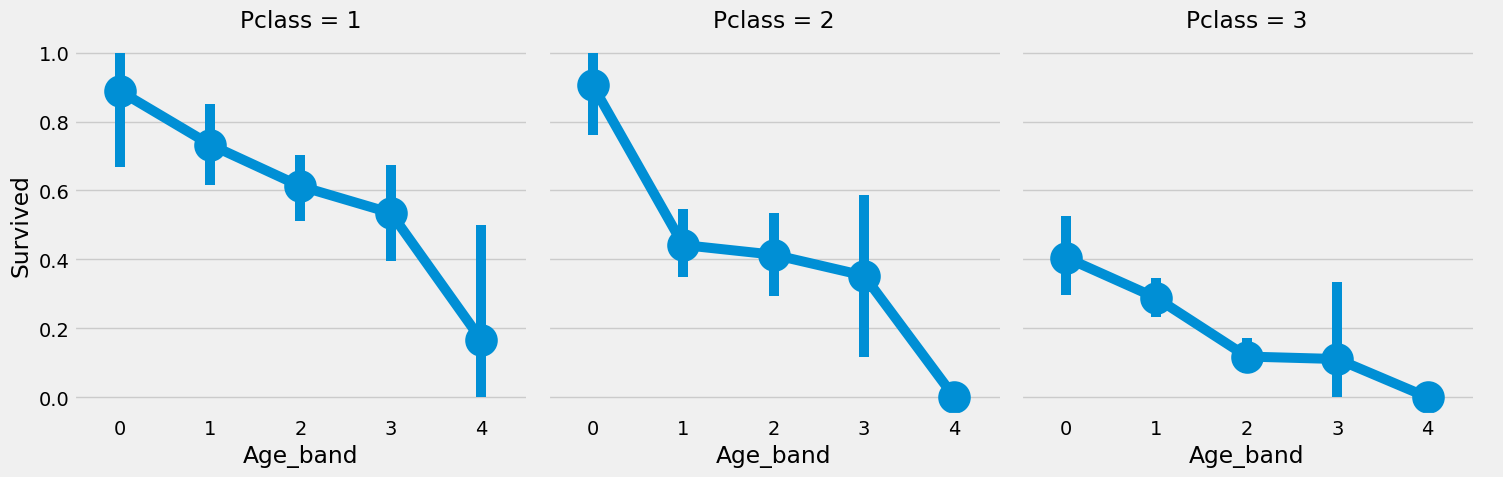

In [44]:
sns.catplot(x='Age_band',y='Survived',data=data, col='Pclass', kind='point')
plt.show()

Pclass와 상관없이 나이가 증가할수록 생존율이 감소한다.

### Family_Size and Alone

At this point, we can create a new feature called "Family_size" and "Alone" and analyse it. This feature is the summation of Parch and SibSp. It gives us a combined data so that we can check if survival rate have anything to do with family size of the passengers. Alone will denote whether a passenger is alone or not.

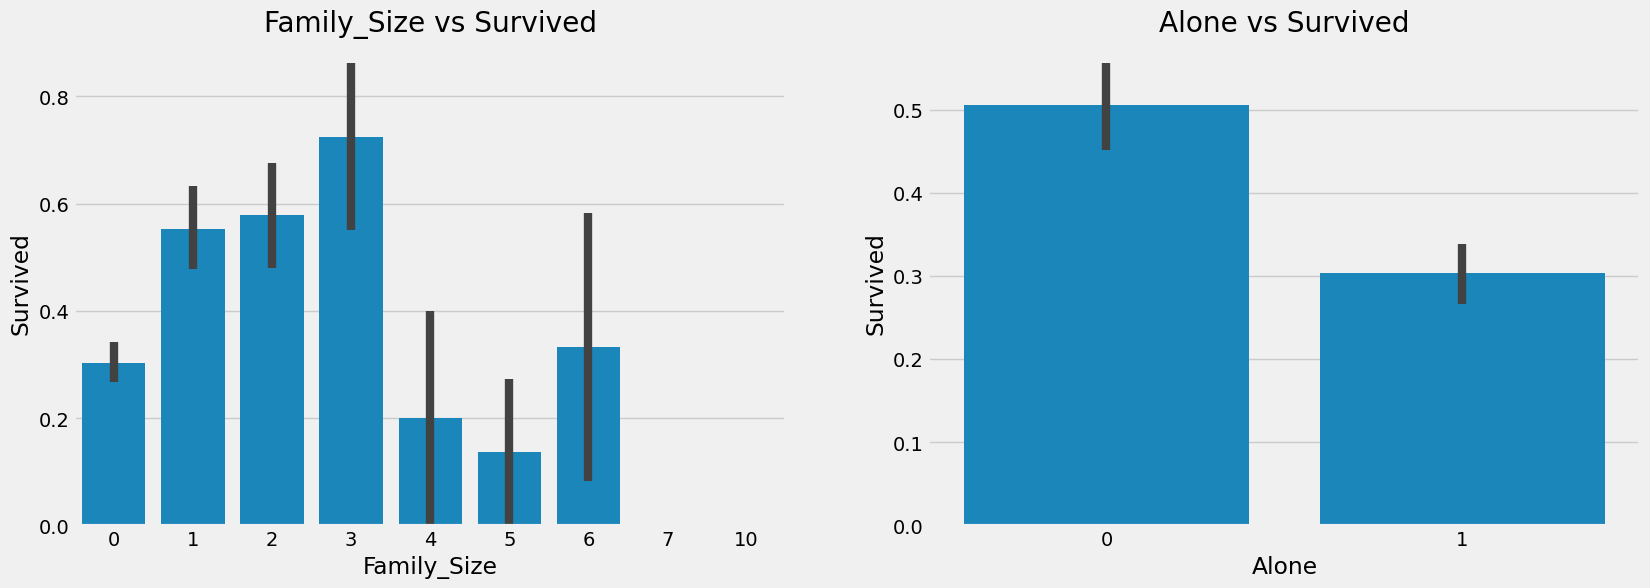

In [45]:
data['Family_Size']=0
data['Family_Size']=data['Parch']+data['SibSp']#family size
data['Alone']=0
data.loc[data.Family_Size==0,'Alone']=1# Alone

f,ax=plt.subplots(1,2,figsize=(18,6))
sns.barplot(x='Family_Size',y='Survived',data=data,ax=ax[0])
ax[0].set_title('Family_Size vs Survived')
sns.barplot(x='Alone',y='Survived',data=data,ax=ax[1])
ax[1].set_title('Alone vs Survived')
plt.close(2)
plt.close(3)
plt.show()

Family_Size=0 은 승객이 혼자라는 것을 의미한다. 혼자인 경우 생존 확률이 매우 낮다. 가족 크기가 4를 넘어가면 생존 확률이 마찬가지로 감소한다. 이는 모델에도 중요한 특징이다.

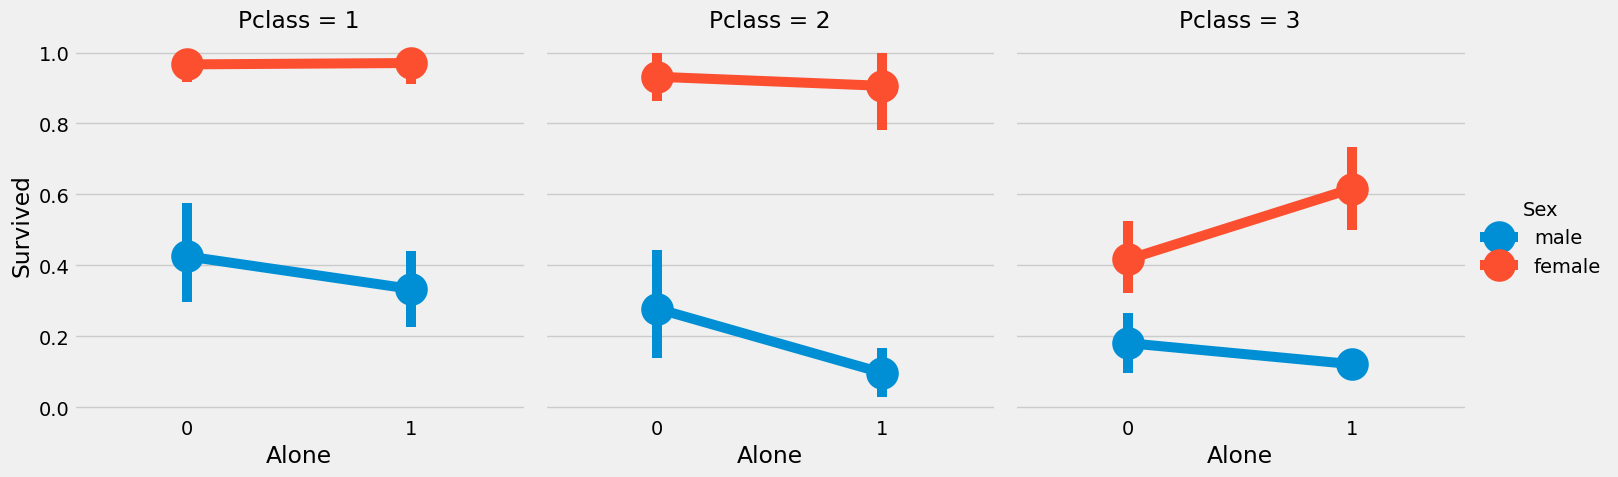

In [46]:
sns.catplot(x='Alone',y='Survived',data=data,hue='Sex',col='Pclass', kind='point')
plt.show()

혼자인 여성이 가족이 있는 여성보다 혼자일 가능성이 높은 Pclass 3을 제외하고는 성별이나 Pclass 상관 없이 위험하다는 것을 알 수 있다.

### Fare_Range
Since fare is also a continous feature, we need to convert it into ordinal value. For this we will use **pandas.qcut.**

So what **qcut** does is it splits or arranges the values according the number of bins we have passed. So if we pass for 5 bins, it will arrange the values equally spaced into 5 seperate bins or value ranges.

In [47]:
data['Fare_Range']=pd.qcut(data['Fare'],4)
data.groupby(['Fare_Range'])['Survived'].mean().to_frame().style.background_gradient(cmap='summer_r')

,Survived
Fare_Range,
"(-0.001, 7.91]",0.197309
"(7.91, 14.454]",0.303571
"(14.454, 31.0]",0.454955
"(31.0, 512.329]",0.581081


위에서 살펴본 것처럼 fare_range가 증가함에 따라 생존 가능성이 높아진다.

Fare_Range 값을 그대로 전달할 수 없기에 Age_Band와 같이 singleton 값으로 변환해야 한다.

In [48]:
data['Fare_cat']=0
data.loc[data['Fare']<=7.91,'Fare_cat']=0
data.loc[(data['Fare']>7.91)&(data['Fare']<=14.454),'Fare_cat']=1
data.loc[(data['Fare']>14.454)&(data['Fare']<=31),'Fare_cat']=2
data.loc[(data['Fare']>31)&(data['Fare']<=513),'Fare_cat']=3

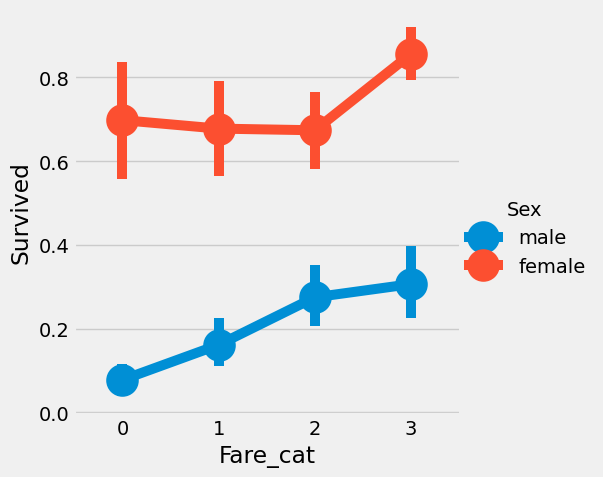

In [49]:
sns.catplot(x='Fare_cat',y='Survived',data=data,hue='Sex', kind='point')
plt.show()

Fare_cat이 증가함에 따라 생존 확률이 높아진다. 이 특징은 Sex와 함께 모델링할 때 중요한 특징이 될 지도 모른다.

### Converting String Values into Numeric
머신러닝 모델에 문자열(string)을 전달할 수 없으므로 Sex, Embarked 등과 같은 피처를 숫자값으로 변환해야 한다.

In [50]:
data['Sex'].replace(['male','female'],[0,1],inplace=True)
data['Embarked'].replace(['S','C','Q'],[0,1,2],inplace=True)
data['Initial'].replace(['Mr','Mrs','Miss','Master','Other'],[0,1,2,3,4],inplace=True)

### Dropping UnNeeded Features
**Name** -> We don't need name feature as it cannot be converted into any categorical value.

**Age** -> We have the Age_band feature, so no need of this.

**Ticket** -> It is any random string that cannot be categorised.

**Fare** -> We have the Fare_cat feature, so unneeded

**Cabin** -> A lot of NaN values and also many passengers have multiple cabins. So this is a useless feature.

**Fare_Range** -> We have the fare_cat feature.

**PassengerId** -> Cannot be categorised.

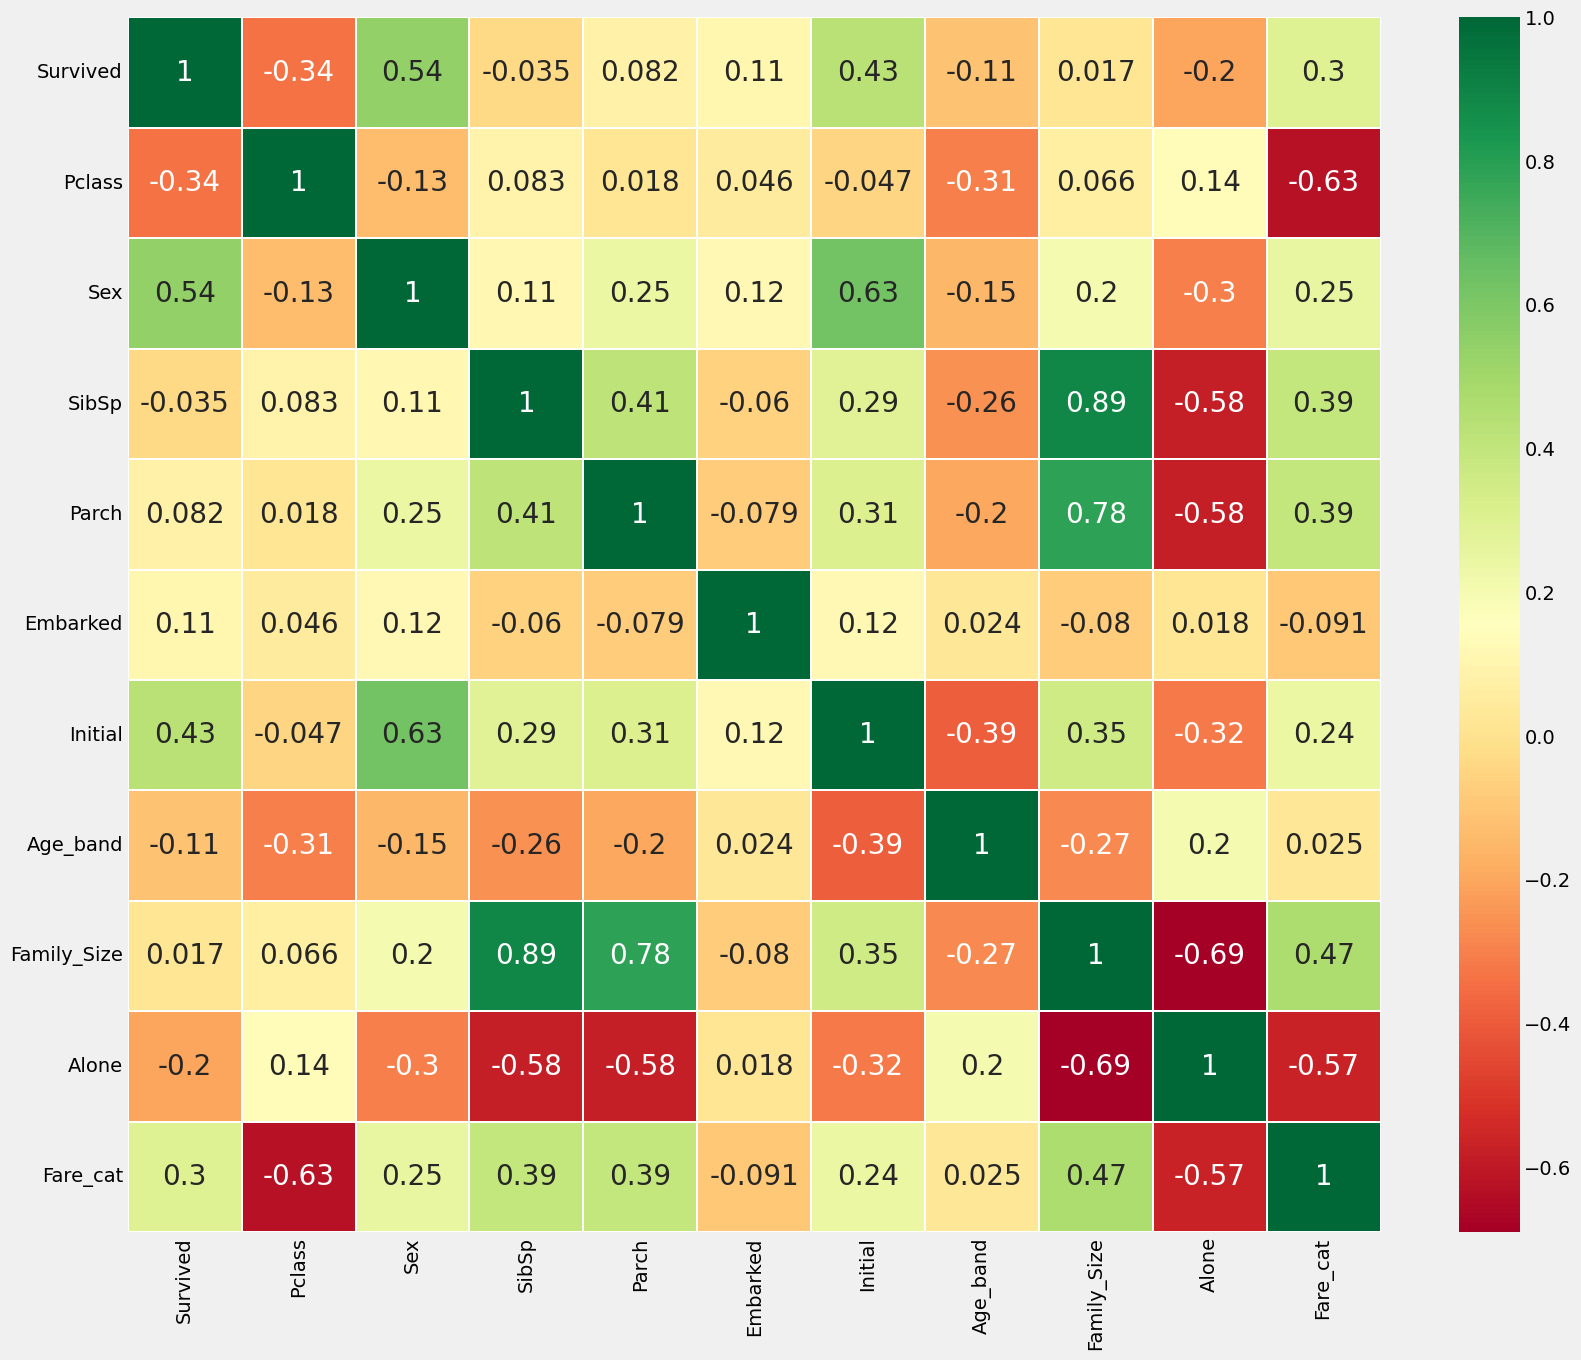

In [51]:
data.drop(['Name','Age','Ticket','Fare','Cabin','Fare_Range','PassengerId'],axis=1,inplace=True)
sns.heatmap(data.corr(),annot=True,cmap='RdYlGn',linewidths=0.2,annot_kws={'size':20})
fig=plt.gcf()
fig.set_size_inches(18,15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

위의 상관관계 plot에서 positively related features를 볼 수 있다.

Some of them being SibSp andd Family_Size and Parch and Family_Size and some negative ones like Alone and Family_Size.

## Part3: Predictive Modeling
We have gained some insights from the EDA part. But with that, we cannot accurately predict or tell whether a passenger will survive or die. So now we will predict the whether the Passenger will survive or not using some great Classification Algorithms.Following are the algorithms I will use to make the model:

1) Logistic Regression
2) Support Vector Machines(Linear and radial)
3) Random Forest
4) K-Nearest Neighbours
5) Naive Bayes
6) Decision Tree
7) Logistic Regression

In [52]:
# importing all the required ML packages
from sklearn.linear_model import LogisticRegression # logistic regression
from sklearn import svm # support vector Machine
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.neighbors import KNeighborsClassifier # KNN
from sklearn.naive_bayes import GaussianNB # Naive bayes
from sklearn.tree import DecisionTreeClassifier # Decision Tree
from sklearn.model_selection import train_test_split # training and testing data split
from sklearn import metrics # accuracy measure
from sklearn.metrics import confusion_matrix # for confusion matrix

In [53]:
train,test=train_test_split(data,test_size=0.3,random_state=0,stratify=data['Survived'])
train_X=train[train.columns[1:]]
train_Y=train[train.columns[:1]]
test_X=test[test.columns[1:]]
test_Y=test[test.columns[:1]]
X=data[data.columns[1:]]
Y=data['Survived']

#### Radial Support Vector Machines(rbf-SVM)

In [54]:
model=svm.SVC(kernel='rbf',C=1,gamma=0.1)
model.fit(train_X,train_Y)
prediction1=model.predict(test_X)
print('Accuracy for rbf SVM is ',metrics.accuracy_score(prediction1,test_Y))

Accuracy for rbf SVM is  0.835820895522388


#### Linear Support Vector Machine(linear-SVM)

In [55]:
model=svm.SVC(kernel='linear',C=0.1,gamma=0.1)
model.fit(train_X,train_Y)
prediction2=model.predict(test_X)
print('Accuracy for linear SVM is',metrics.accuracy_score(prediction2,test_Y))

Accuracy for linear SVM is 0.8171641791044776


#### Logistic Regression

In [56]:
model = LogisticRegression()
model.fit(train_X,train_Y)
prediction3=model.predict(test_X)
print('The accuracy of the Logistic Regression is',metrics.accuracy_score(prediction3,test_Y))

The accuracy of the Logistic Regression is 0.8134328358208955


#### Decision Tree

In [57]:
model=DecisionTreeClassifier()
model.fit(train_X,train_Y)
prediction4=model.predict(test_X)
print('The accuracy of the Decision Tree is',metrics.accuracy_score(prediction4,test_Y))

The accuracy of the Decision Tree is 0.8022388059701493


#### K-Nearest Neighbours(KNN)

In [58]:
model=KNeighborsClassifier()
model.fit(train_X,train_Y)
prediction5=model.predict(test_X)
print('The accuracy of the KNN is',metrics.accuracy_score(prediction5,test_Y))

The accuracy of the KNN is 0.8134328358208955


이제 n_neighbours 속성 값을 변경함에 따라 KNN 모델의 정확도가 달라진다. 기본값은 5이다. n_neighbours의 다양한 값에 대한 정확도를 확인해 보겠다.

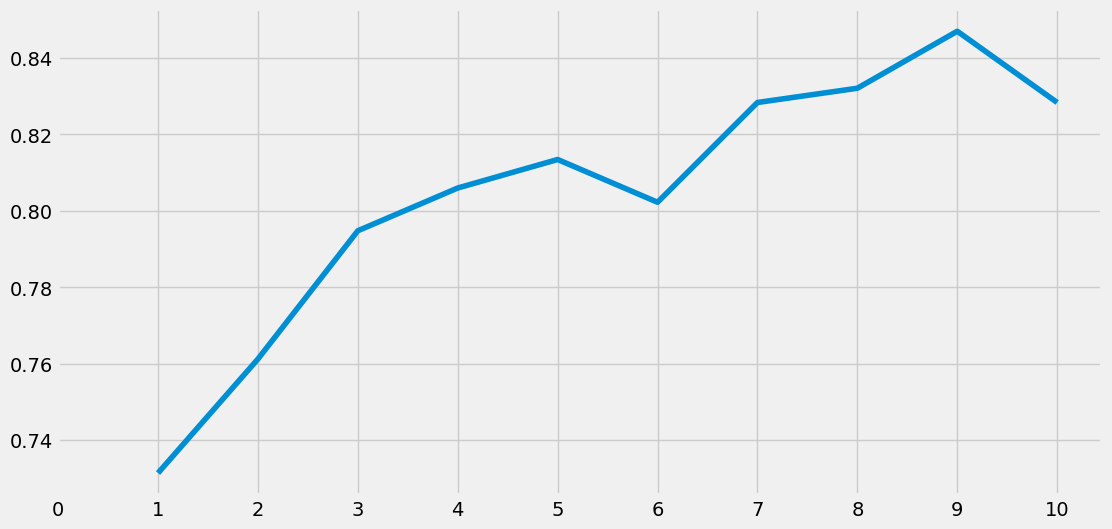

Accuracies for different values of n are: [0.73134328 0.76119403 0.79477612 0.80597015 0.81343284 0.80223881
 0.82835821 0.83208955 0.84701493 0.82835821] with the max value as  0.8470149253731343


In [61]:
a_index=list(range(1,11))
a=pd.Series()
x=[0,1,2,3,4,5,6,7,8,9,10]

for i in list(range(1,11)):
  model=KNeighborsClassifier(n_neighbors=i)
  model.fit(train_X,train_Y)
  prediction=model.predict(test_X)
  a = pd.concat([a, pd.Series([metrics.accuracy_score(prediction, test_Y)])], ignore_index=True)
plt.plot(a_index, a)
plt.xticks(x)
fig=plt.gcf()
fig.set_size_inches(12,6)
plt.show()
print('Accuracies for different values of n are:',a.values,'with the max value as ',a.values.max())

#### Gaussian Naive Bayes

In [62]:
model=GaussianNB()
model.fit(train_X,train_Y)
prediction6=model.predict(test_X)
print('The accuracy of the NaiveBayes is',metrics.accuracy_score(prediction6,test_Y))

The accuracy of the NaiveBayes is 0.8134328358208955


#### Random Forests

In [63]:
model=RandomForestClassifier(n_estimators=100)
model.fit(train_X,train_Y)
prediction7=model.predict(test_X)
print('The accuracy of the Random Forests is',metrics.accuracy_score(prediction7,test_Y))

The accuracy of the Random Forests is 0.8134328358208955


모델의 정확성만이 분류기의 견고성을 결정하는 유일한 요소는 아니다. 분류기가 학습 데이터를 통해 학습되고 테스트 데이터를 통해 테스트되었으며 90%의 정확도를 기록했다고 가정해 보자.

이제 이것은 분류기로서는 매우 좋은 정확도인 것 같지만, 새로 출시되는 모든 테스트 세트에 대해 90%가 된다는 것을 확인할 수 있을까? 분류기가 어떤 인스턴스를 사용하여 스스로 학습할지 결정할 수 없기 때문에 대답은 'No'이다. 학습 및 테스트 데이터가 변경되면 정확도도 달라진다. 증가하거나 감소할 수 있다. 이를 Model Variance 라고 한다.

이를 극복하고 일반화된 모델을 얻기 위해 교차 검증을 활용한다.

### Cross Validation
Many a times, the data is imbalanced, i.e there may be a high number of class1 instances but less number of other class instances. Thus we should train and test our algorithm on each and every instance of the dataset. Then we can take an average of all the noted accuracies over the dataset.

1)The K-Fold Cross Validation works by first dividing the dataset into k-subsets.

2)Let's say we divide the dataset into (k=5) parts. We reserve 1 part for testing and train the algorithm over the 4 parts.

3)We continue the process by changing the testing part in each iteration and training the algorithm over the other parts. The accuracies and errors are then averaged to get a average accuracy of the algorithm.

This is called K-Fold Cross Validation.

4)An algorithm may underfit over a dataset for some training data and sometimes also overfit the data for other training set. Thus with cross-validation, we can achieve a generalised model.

In [64]:
from sklearn.model_selection import KFold # for K-fold cross validation
from sklearn.model_selection import cross_val_score # score evaluation
from sklearn.model_selection import cross_val_predict # prediction
kfold = KFold(n_splits=10, shuffle=True, random_state=22) # k=10, split the data into 10 equal parts
xyz=[]
accuracy=[]
std=[]
classifiers=['Linear Svm','Radial Svm','Logistic Regression','KNN','Decision Tree','Naive Bayes','Random Forest']
models=[svm.SVC(kernel='linear'),svm.SVC(kernel='rbf'),LogisticRegression(),KNeighborsClassifier(n_neighbors=9),DecisionTreeClassifier(),GaussianNB(),RandomForestClassifier(n_estimators=100)]
for i in models:
    model = i
    cv_result = cross_val_score(model,X,Y, cv = kfold,scoring = "accuracy")
    cv_result=cv_result
    xyz.append(cv_result.mean())
    std.append(cv_result.std())
    accuracy.append(cv_result)
new_models_dataframe2=pd.DataFrame({'CV Mean':xyz,'Std':std},index=classifiers)
new_models_dataframe2

,CV Mean,Std
Linear Svm,0.784607,0.057841
Radial Svm,0.828377,0.057096
Logistic Regression,0.799176,0.040154
KNN,0.808140,0.035630
Decision Tree,0.805855,0.048121
Naive Bayes,0.795843,0.054861
Random Forest,0.813720,0.044011


<Axes: >

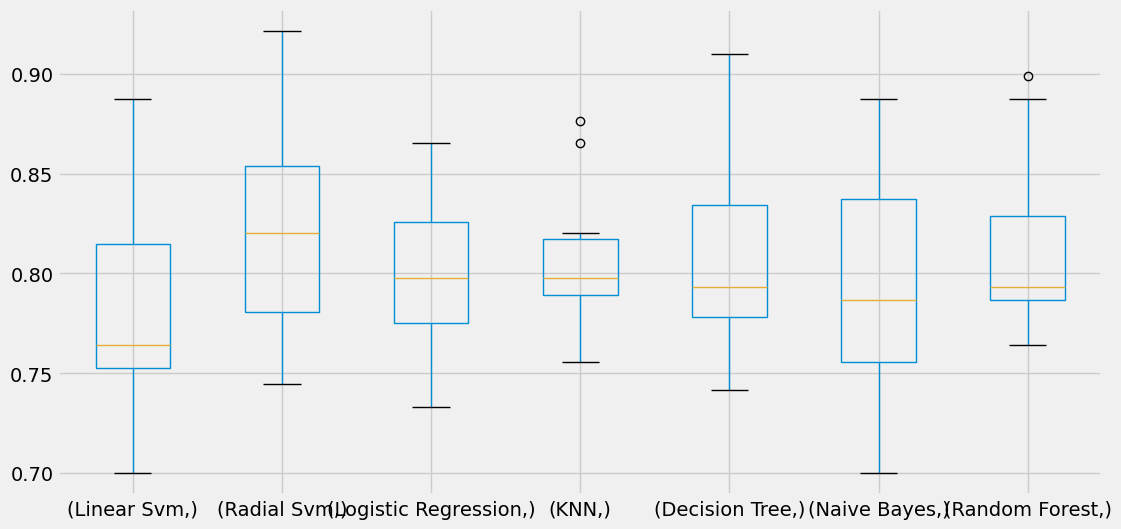

In [65]:
plt.subplots(figsize=(12,6))
box=pd.DataFrame(accuracy,index=[classifiers])
box.T.boxplot()

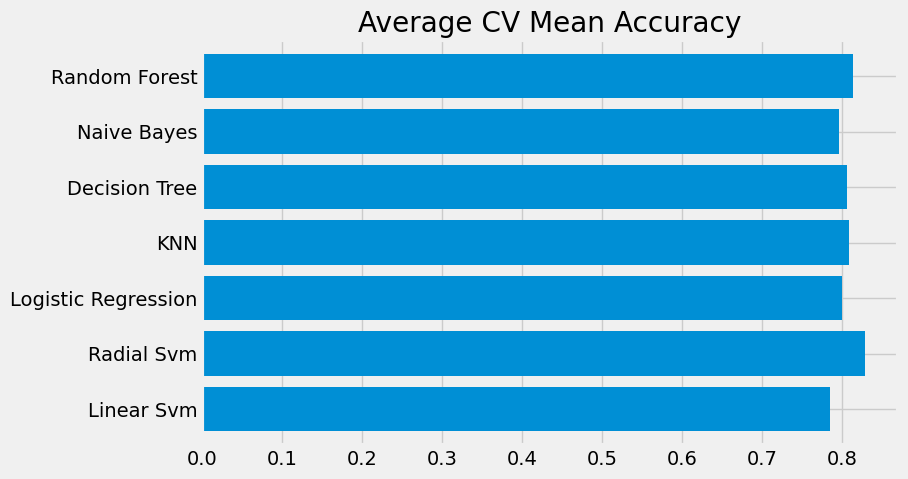

In [66]:
new_models_dataframe2['CV Mean'].plot.barh(width=0.8)
plt.title('Average CV Mean Accuracy')
fig=plt.gcf()
fig.set_size_inches(8,5)
plt.show()

불균형으로 인해 분류 정확도가 때때로 오해의 소지가 있을 수 있다. 모델이 어디에서 잘못되었는지 또는 모델이 예측한 클래스를 보여주는 confusion matrix를 통해 요약된 결과를 얻을 수 있다.

### Confusion Matrix
It gives the number of correct and incorrect classifications made by the classifier.

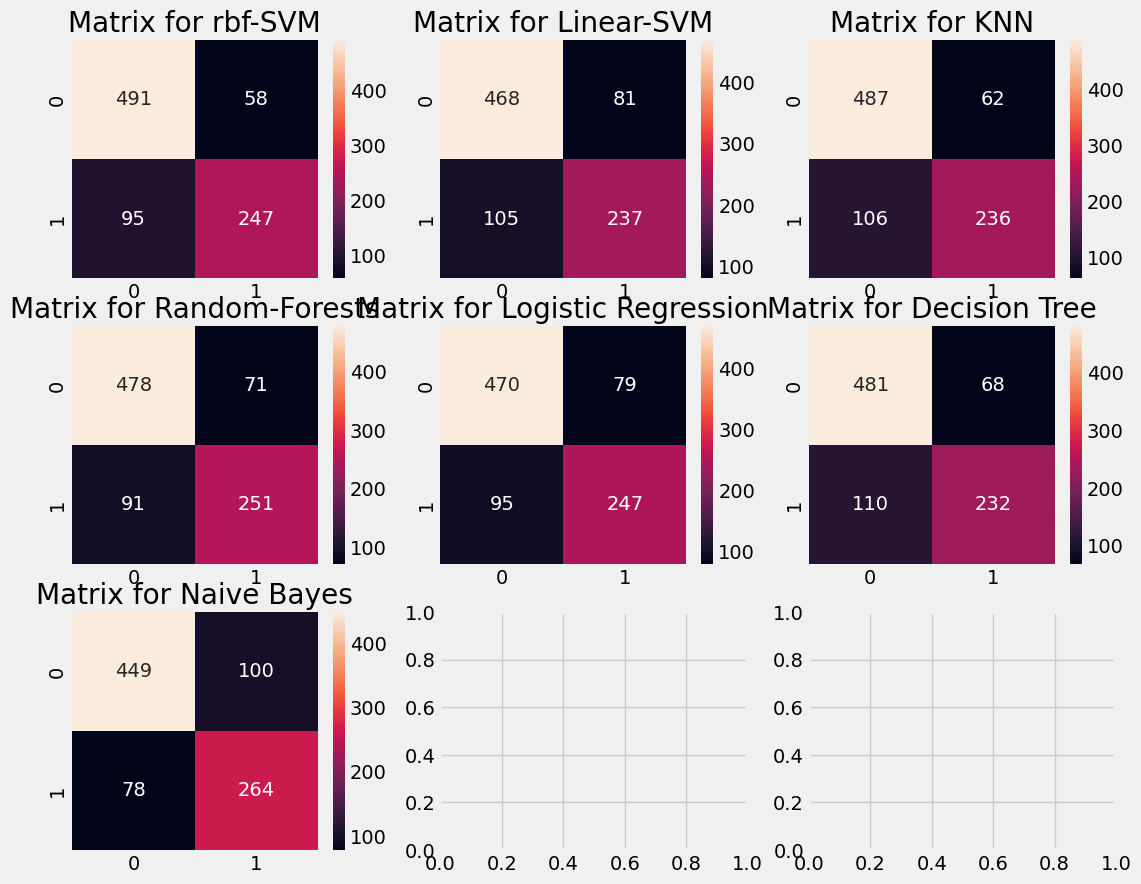

In [67]:
f,ax=plt.subplots(3,3,figsize=(12,10))
y_pred = cross_val_predict(svm.SVC(kernel='rbf'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,0],annot=True,fmt='2.0f')
ax[0,0].set_title('Matrix for rbf-SVM')
y_pred = cross_val_predict(svm.SVC(kernel='linear'),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,1],annot=True,fmt='2.0f')
ax[0,1].set_title('Matrix for Linear-SVM')
y_pred = cross_val_predict(KNeighborsClassifier(n_neighbors=9),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[0,2],annot=True,fmt='2.0f')
ax[0,2].set_title('Matrix for KNN')
y_pred = cross_val_predict(RandomForestClassifier(n_estimators=100),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,0],annot=True,fmt='2.0f')
ax[1,0].set_title('Matrix for Random-Forests')
y_pred = cross_val_predict(LogisticRegression(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,1],annot=True,fmt='2.0f')
ax[1,1].set_title('Matrix for Logistic Regression')
y_pred = cross_val_predict(DecisionTreeClassifier(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[1,2],annot=True,fmt='2.0f')
ax[1,2].set_title('Matrix for Decision Tree')
y_pred = cross_val_predict(GaussianNB(),X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,y_pred),ax=ax[2,0],annot=True,fmt='2.0f')
ax[2,0].set_title('Matrix for Naive Bayes')
plt.subplots_adjust(hspace=0.2,wspace=0.2)
plt.show()

left diagonal은 각 클래스에 대해 올바른 예측을 한 획수를 나타내고 right diagonal은 잘못된 예측을 한 횟수를 나타낸다. rbf-SVM의 첫 번째 그래프를 살펴보자.

1)올바른 예측의 수는 491(사망) + 247(생존)이며, 평균 CV 정확도는 (491+247)/891 = 82.8%로 이전에 얻었다.

2)오류 -> 58명의 사망자를 생존자로 잘못 분류하고 95명을 생존자로 분류했다. 따라서 사망자를 생존자로 예측하여 더 많은 실수를 저질렀다.

모든 행렬을 보면 rbf-SVM이 죽은 승객을 정확하게 예측할 확률이 더 높지만, 나이브베이즈는 살아남은 승객을 정확하게 예측할 확률이 더 높다고 말할 수 있다.

### Hyper-Parameters Tuning
머신 러닝 모델은 블랙박스 같다. 이 블랙박스에는 몇 가지 기본 매개변수 값이 있으며, 이를 조정하거나 변경하여 더 나은 모델을 얻을 수 있다. SVM 모델의 C와 감마 및 분류기마다 유사하게 다른 매개변수를 하이퍼파라미터라고 하며, 이를 조정하여 알고리즘의 학습 속도를 변경하고 더 나은 모델을 얻을 수 있다. 이를 하이퍼파라미터 튜닝이라고 한다.

우리는 SVM과 랜덤 포레스트라는 두 가지 최고의 분류기를 위해 하이퍼파라미터를 조정할 것이다.

#### SVM

In [68]:
from sklearn.model_selection import GridSearchCV
C=[0.05,0.1,0.2,0.3,0.25,0.4,0.5,0.6,0.7,0.8,0.9,1]
gamma=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
kernel=['rbf','linear']
hyper={'kernel':kernel,'C':C,'gamma':gamma}
gd=GridSearchCV(estimator=svm.SVC(),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
0.8282593685267716
SVC(C=0.4, gamma=0.3)


#### Random Forests

In [69]:
n_estimators=range(100,1000,100)
hyper={'n_estimators':n_estimators}
gd=GridSearchCV(estimator=RandomForestClassifier(random_state=0),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
0.819327098110602
RandomForestClassifier(n_estimators=300, random_state=0)


Rbf-Svm의 최고 점수는 82.82%이며, C=0.05와 gamma=0.1이다. RandomForest의 경우, n_estimators=900의 점수는 약 81.8%이다.

### Ensembling
앙상블은 모델의 정확도나 성능을 높이는 좋은 방법이다. 간단히 말해, 다양한 간단한 모델을 결합하여 하나의 강력한 모델을 만드는 것이다.

휴대폰을 구입하고 다양한 매개변수를 기반으로 많은 사람에게 휴대폰에 대해 물어보고 싶다고 가정해 보자. 따라서 다양한 매개변수를 분석한 후 단일 제품에 대해 강력한 판단을 내릴 수 있다. 이것이 바로 앙상블로, 모델의 안정성을 향상시킨다. 앙상블은 다음과 같은 방식으로 수행할 수 있다:

1)Voting Classifier

2)Bagging

3)Boosting.

### Voting Classifier
다양한 간단한 머신 러닝 모델의 예측을 결합하는 가장 간단한 방법. 모든 하위 모델의 예측을 기반으로 평균 예측 결과를 제공한다. 하위 모델 또는 기본 모델은 모두 다른 유형이다.

In [70]:
from sklearn.ensemble import VotingClassifier
ensemble_lin_rbf=VotingClassifier(estimators=[('KNN',KNeighborsClassifier(n_neighbors=10)),
                                              ('RBF',svm.SVC(probability=True,kernel='rbf',C=0.5,gamma=0.1)),
                                              ('RFor',RandomForestClassifier(n_estimators=500,random_state=0)),
                                              ('LR',LogisticRegression(C=0.05)),
                                              ('DT',DecisionTreeClassifier(random_state=0)),
                                              ('NB',GaussianNB()),
                                              ('svm',svm.SVC(kernel='linear',probability=True))
                                             ],
                       voting='soft').fit(train_X,train_Y)
print('The accuracy for ensembled model is:',ensemble_lin_rbf.score(test_X,test_Y))
cross=cross_val_score(ensemble_lin_rbf,X,Y, cv = 10,scoring = "accuracy")
print('The cross validated score is',cross.mean())

The accuracy for ensembled model is: 0.8171641791044776
The cross validated score is 0.8249188514357053


### Bagging
배깅은 일반적인 앙상블 방법. 이 방법은 데이터셋의 작은 파티션에 유사한 분류기를 적용한 다음 모든 예측의 평균을 구하는 방식으로 작동한다. 평균화로 인해 분산이 감소한다. 투표 분류기와 달리 배깅은 유사한 분류기를 사용한다.

#### Bagged KNN
배깅은 분산이 높은 모델에서 가장 잘 작동한다. 예를 들어 Decision Tree 또는 Random Forest가 있다. 작은 값의 n_neighbours 값을 가진 KNN을 작은 값의 n_neighbours 값으로 사용할 수 있다.

In [71]:
from sklearn.ensemble import BaggingClassifier
model=BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=3),random_state=0,n_estimators=700)
model.fit(train_X,train_Y)
prediction=model.predict(test_X)
print('The accuracy for bagged KNN is:',metrics.accuracy_score(prediction,test_Y))
result=cross_val_score(model,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for bagged KNN is:',result.mean())

The accuracy for bagged KNN is: 0.832089552238806
The cross validated score for bagged KNN is: 0.8104244694132333


#### Bagged DecisionTree

In [72]:
model=BaggingClassifier(estimator=DecisionTreeClassifier(),random_state=0,n_estimators=100)
model.fit(train_X,train_Y)
prediction=model.predict(test_X)
print('The accuracy for bagged Decision Tree is:',metrics.accuracy_score(prediction,test_Y))
result=cross_val_score(model,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for bagged Decision Tree is:',result.mean())

The accuracy for bagged Decision Tree is: 0.8208955223880597
The cross validated score for bagged Decision Tree is: 0.8171410736579275


### Boosting
부스팅은 분류기의 순차적 학습을 사용하는 앙상블 기법. 약한 모델을 단계별로 향상시키는 것이다. 부스팅은 다음과 같이 작동한다:

모델은 먼저 전체 데이터 세트에 대해 훈련된다. 이제 모델은 일부 인스턴스는 맞추고 일부 인스턴스는 틀릴 수 있다. 이제 다음 반복에서는 학습자가 잘못 예측된 인스턴스에 더 집중하거나 더 많은 가중치를 부여한다. 따라서 학습자는 잘못된 인스턴스를 올바르게 예측하려고 한다. 이제 이 반복 과정은 계속되며 정확도에 한계에 도달할 때까지 모델에 새로운 분류기가 추가된다.

#### AdaBoost(Adaptive Boosting)
The weak learner or estimator in this case is a Decision Tree. But we can change the dafault base_estimator to any algorithm of our choice.

In [73]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier(n_estimators=200,random_state=0,learning_rate=0.1)
result=cross_val_score(ada,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for AdaBoost is:',result.mean())

The cross validated score for AdaBoost is: 0.8136828963795256


#### Stochastic Gradient Boosting
Here too the weak learner is a Decision Tree.

In [74]:
from sklearn.ensemble import GradientBoostingClassifier
grad=GradientBoostingClassifier(n_estimators=500,random_state=0,learning_rate=0.1)
result=cross_val_score(grad,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for Gradient Boosting is:',result.mean())

The cross validated score for Gradient Boosting is: 0.8115230961298376


#### XGBoost

In [75]:
import xgboost as xg
xgboost=xg.XGBClassifier(n_estimators=900,learning_rate=0.1)
result=cross_val_score(xgboost,X,Y,cv=10,scoring='accuracy')
print('The cross validated score for XGBoost is:',result.mean())

The cross validated score for XGBoost is: 0.8182771535580524


우리는 AdaBoost의 최고 정확도를 얻었다. 하이퍼파라미터 튜닝을 통해 이를 높이도록 시도해보자.

#### Hyper-Parameter Tuning for AdaBoost

In [76]:
n_estimators=list(range(100,1100,100))
learn_rate=[0.05,0.1,0.2,0.3,0.25,0.4,0.5,0.6,0.7,0.8,0.9,1]
hyper={'n_estimators':n_estimators,'learning_rate':learn_rate}
gd=GridSearchCV(estimator=AdaBoostClassifier(),param_grid=hyper,verbose=True)
gd.fit(X,Y)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
0.8293892411022534
AdaBoostClassifier(learning_rate=0.4, n_estimators=800)


#### Confusion Matrix for the Best Model

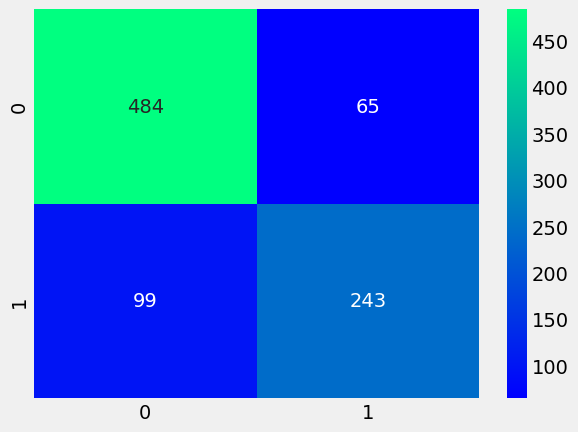

In [77]:
ada=AdaBoostClassifier(n_estimators=200,random_state=0,learning_rate=0.05)
result=cross_val_predict(ada,X,Y,cv=10)
sns.heatmap(confusion_matrix(Y,result),cmap='winter',annot=True,fmt='2.0f')
plt.show()

## Feature Importance

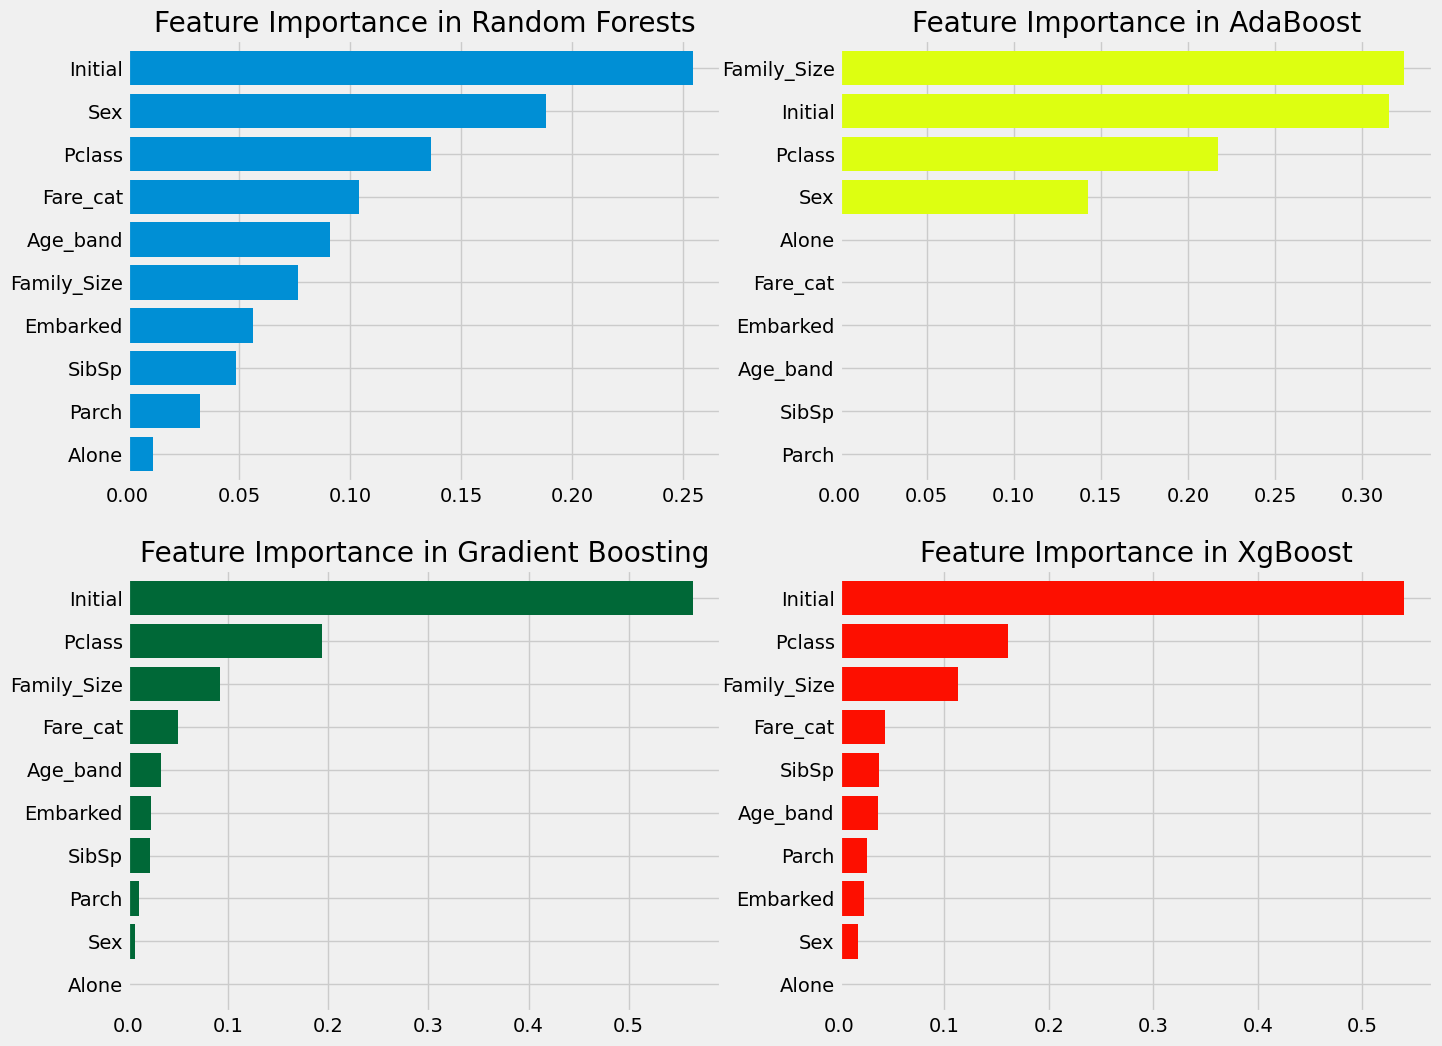

In [78]:
f,ax=plt.subplots(2,2,figsize=(15,12))
model=RandomForestClassifier(n_estimators=500,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[0,0])
ax[0,0].set_title('Feature Importance in Random Forests')
model=AdaBoostClassifier(n_estimators=200,learning_rate=0.05,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[0,1],color='#ddff11')
ax[0,1].set_title('Feature Importance in AdaBoost')
model=GradientBoostingClassifier(n_estimators=500,learning_rate=0.1,random_state=0)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[1,0],cmap='RdYlGn_r')
ax[1,0].set_title('Feature Importance in Gradient Boosting')
model=xg.XGBClassifier(n_estimators=900,learning_rate=0.1)
model.fit(X,Y)
pd.Series(model.feature_importances_,X.columns).sort_values(ascending=True).plot.barh(width=0.8,ax=ax[1,1],color='#FD0F00')
ax[1,1].set_title('Feature Importance in XgBoost')
plt.show()

RandomForests, AdaBoost 등 다양한 분류기의 중요한 특징을 확인할 수 있다.

1. Some of the common important features are Initial,Fare_cat,Pclass,Family_Size.
2. Sex 피처는 아무런 중요도가 없는 것처럼 보이는데, Sex와 Pclass가 결합된 것이 매우 좋은 차별화 요소라는 것이 보여졌으므로 놀랍다. Sex는 RandomForests에서 매우 중요한 것으로 보인다.

그러나 많은 분류기에서 상위에 있는 Initial 피처를 볼 수 있다. 우리는 이미 Sex와 Initial 사이의 양의 상관관계를 보았기 때문에 둘 다 성별을 의미한다.

3. 마찬가지로 Pclass와 Fare_cat는 승객의 상태와 Alone, Parch, SibSp의 Family_Size를 의미한다.